# Stress Detection pada Mahasiswa
Deteksi tingkat stres mahasiswa berdasarkan pola aktivitas digital dan indikator psikologis.
Model dibangun menggunakan Multi-Layer Perceptron (MLP) dengan TensorFlow Functional API dan Keras.

---
## Step 1 - Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import json

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score, f1_score,
    mean_absolute_error
)
from sklearn.utils.class_weight import compute_class_weight

import keras
from keras import layers, regularizers, callbacks
import keras.ops as ops

SEED = 42
np.random.seed(SEED)

print("Keras version :", keras.__version__)


Keras version : 3.13.2


---
## Step 2 - Load Dataset

In [ ]:
DATASET_PATH = "final_clean_dataset.csv"
DICT_PATH    = "data_dictionary.csv"

df        = pd.read_csv(DATASET_PATH)
data_dict = pd.read_csv(DICT_PATH)

CLASS_NAMES = ["Rendah", "Sedang", "Tinggi"]
PALETTE     = {0: "#4CAF50", 1: "#FF9800", 2: "#F44336"}

print("Shape dataset :", df.shape)
print()
print("Distribusi target:")
vc = df["stress_level"].value_counts().sort_index()
for k, v in vc.items():
    print("  Kelas", k, "(" + CLASS_NAMES[k] + ") :", v, "sampel")
df.head()


Shape dataset : (1000, 24)

Distribusi target:
  Kelas 0 (Rendah) : 338 sampel
  Kelas 1 (Sedang) : 331 sampel
  Kelas 2 (Tinggi) : 331 sampel


,anxiety_level,self_esteem,mental_health_history,depression,headache,sleep_quality,academic_performance,study_load,future_career_concerns,social_support,...,Total_App_Usage_Hours,Daily_Screen_Time_Hours,Number_of_Apps_Used,Social_Media_Usage_Hours,Productivity_App_Usage_Hours,Gaming_App_Usage_Hours,digital_overload_score,productivity_balance_score,study_stress_ratio,mental_risk_score
0,14,20,0,11,2,2,3,2,3,2,...,2.61,7.15,24,4.43,0.55,2.40,13.98,0.152355,0.666667,30
1,15,8,1,15,5,1,1,4,5,1,...,2.13,13.79,18,4.67,4.42,2.43,20.89,1.412141,2.000000,39
2,12,18,1,14,2,2,2,3,2,2,...,7.28,4.50,11,4.58,1.71,2.83,11.91,0.206522,1.000000,31
3,16,12,1,15,4,1,2,4,4,1,...,1.20,6.29,21,3.18,3.42,4.58,14.05,1.554545,2.000000,40
4,16,28,0,7,2,5,4,3,2,1,...,6.31,12.59,14,3.15,0.13,4.00,19.74,0.017784,0.500000,33


---
## Step 3 - Data Dictionary

In [ ]:
data_dict.style.set_properties(**{"text-align": "left"}).hide(axis="index")


column_name,description,data_type,role
anxiety_level,Tingkat kecemasan mahasiswa.,int64,feature
self_esteem,Tingkat kepercayaan diri mahasiswa.,int64,feature
mental_health_history,Riwayat kesehatan mental.,int64,feature
depression,Tingkat depresi mahasiswa.,int64,feature
headache,Intensitas sakit kepala.,int64,feature
sleep_quality,Kualitas tidur mahasiswa.,int64,feature
academic_performance,Performa akademik mahasiswa.,int64,feature
study_load,Beban belajar mahasiswa.,int64,feature
future_career_concerns,Kekhawatiran terhadap karier masa depan.,int64,feature
social_support,Dukungan sosial yang diterima mahasiswa.,int64,feature


---
## Step 4 - Validasi Dataset

In [ ]:
print("=== Cek Missing Values ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Tidak ada missing values.")
print()

print("=== Cek Duplikat ===")
n_dup = df.duplicated().sum()
print("Jumlah duplikat :", n_dup)
print()

print("=== Cek Tipe Data ===")
print(df.dtypes)
print()

print("=== Cek Nilai Negatif pada Fitur Non-Negatif ===")
non_neg_cols = [
    "Total_App_Usage_Hours", "Daily_Screen_Time_Hours",
    "Social_Media_Usage_Hours", "Productivity_App_Usage_Hours",
    "Gaming_App_Usage_Hours", "digital_overload_score",
    "productivity_balance_score", "study_stress_ratio"
]
all_clean = True
for col in non_neg_cols:
    n_neg = (df[col] < 0).sum()
    if n_neg > 0:
        print("  " + col + ":", n_neg, "nilai negatif")
        all_clean = False
if all_clean:
    print("Tidak ada nilai negatif.")
print()

print("=== Cek Range Nilai Fitur Ordinal ===")
ordinal_ranges = {
    "anxiety_level"          : (0, 21),
    "self_esteem"            : (0, 30),
    "depression"             : (0, 27),
    "headache"               : (0, 5),
    "sleep_quality"          : (0, 5),
    "academic_performance"   : (0, 5),
    "study_load"             : (0, 5),
    "future_career_concerns" : (0, 5),
    "social_support"         : (0, 3),
    "peer_pressure"          : (0, 5),
    "bullying"               : (0, 5),
    "mental_health_history"  : (0, 1),
    "stress_level"           : (0, 2),
}
all_ok = True
for col, (lo, hi) in ordinal_ranges.items():
    out = df[(df[col] < lo) | (df[col] > hi)]
    if len(out) > 0:
        print("  " + col + ":", len(out), "nilai di luar range [" + str(lo) + ", " + str(hi) + "]")
        all_ok = False
if all_ok:
    print("Semua fitur ordinal dalam range yang valid.")
print()

print("=== Ringkasan Validasi ===")
print("Missing values  :", df.isnull().sum().sum())
print("Duplikat        :", df.duplicated().sum())
print("Shape akhir     :", df.shape)
print("Dataset siap digunakan.")


=== Cek Missing Values ===
Tidak ada missing values.

=== Cek Duplikat ===
Jumlah duplikat : 0

=== Cek Tipe Data ===
anxiety_level                     int64
self_esteem                       int64
mental_health_history             int64
depression                        int64
headache                          int64
sleep_quality                     int64
academic_performance              int64
study_load                        int64
future_career_concerns            int64
social_support                    int64
peer_pressure                     int64
bullying                          int64
stress_level                      int64
Age                               int64
Total_App_Usage_Hours           float64
Daily_Screen_Time_Hours         float64
Number_of_Apps_Used               int64
Social_Media_Usage_Hours        float64
Productivity_App_Usage_Hours    float64
Gaming_App_Usage_Hours          float64
digital_overload_score          float64
productivity_balance_score      float64
st

---
## Step 5 - Exploratory Data Analysis

In [ ]:
df.describe().round(2).T.style.background_gradient(cmap="Blues")


,count,mean,std,min,25%,50%,75%,max
anxiety_level,1000.000000,11.060000,6.080000,0.000000,6.000000,11.000000,16.000000,21.000000
self_esteem,1000.000000,17.870000,8.940000,0.000000,11.000000,19.000000,26.000000,30.000000
mental_health_history,1000.000000,0.490000,0.500000,0.000000,0.000000,0.000000,1.000000,1.000000
depression,1000.000000,12.510000,7.680000,0.000000,7.000000,12.000000,19.000000,27.000000
headache,1000.000000,2.500000,1.400000,0.000000,1.000000,3.000000,3.000000,5.000000
sleep_quality,1000.000000,2.670000,1.540000,0.000000,1.000000,3.000000,4.000000,5.000000
academic_performance,1000.000000,2.780000,1.400000,0.000000,2.000000,2.000000,4.000000,5.000000
study_load,1000.000000,2.630000,1.310000,0.000000,2.000000,2.000000,3.000000,5.000000
future_career_concerns,1000.000000,2.650000,1.530000,0.000000,1.000000,2.000000,4.000000,5.000000
social_support,1000.000000,1.900000,1.040000,0.000000,1.000000,2.000000,3.000000,3.000000


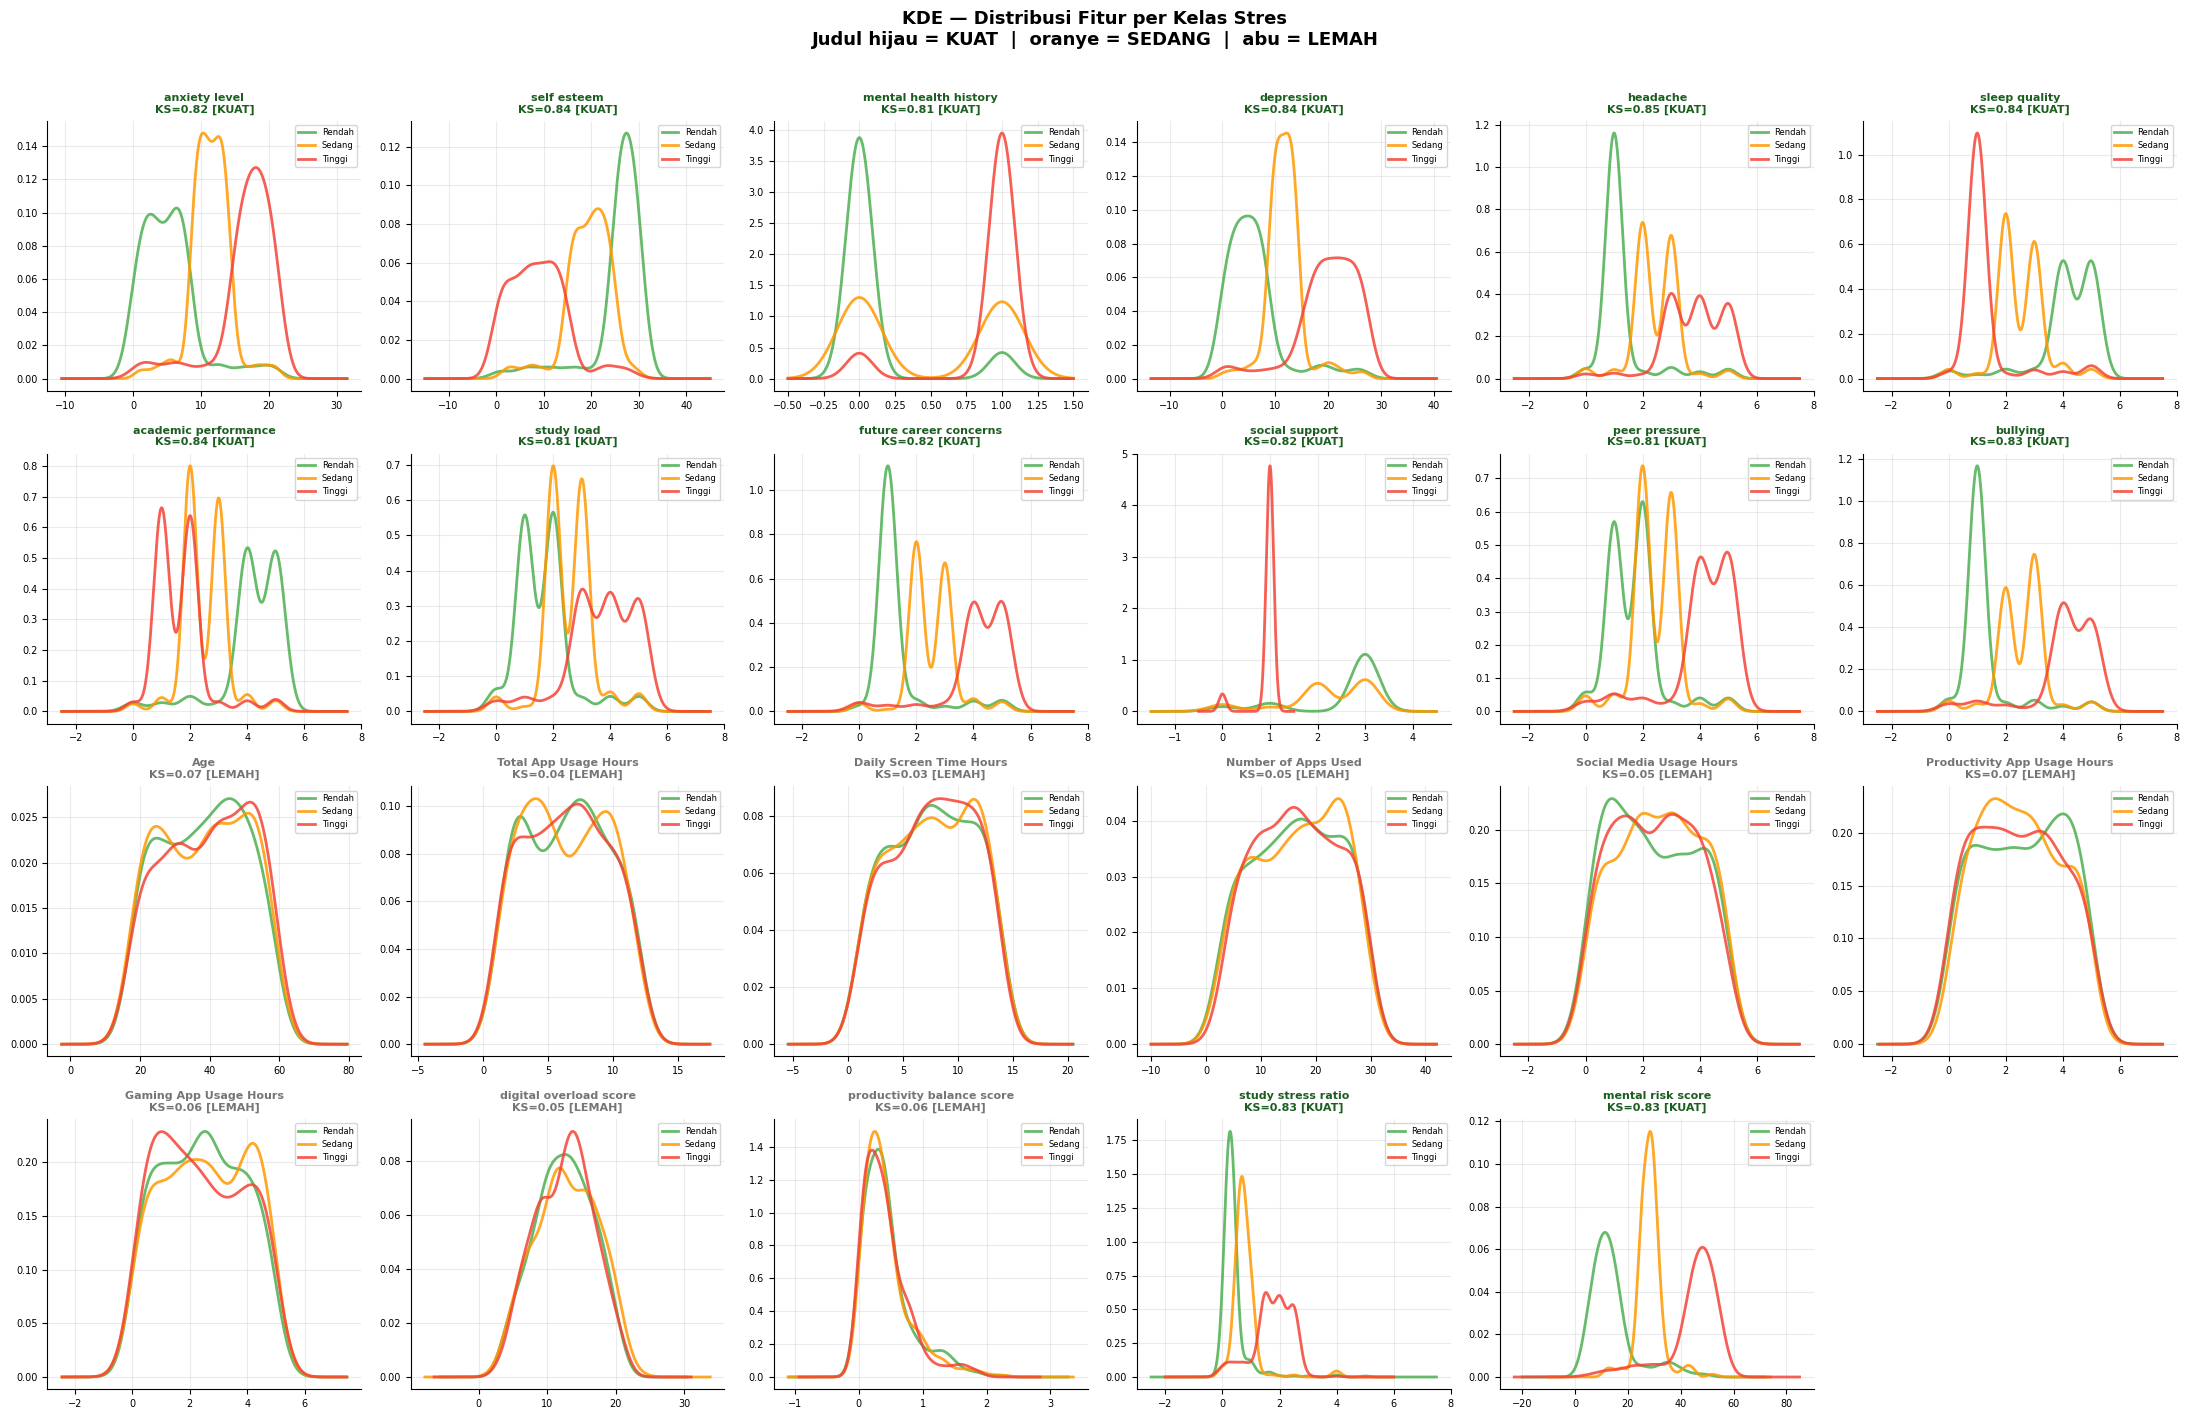

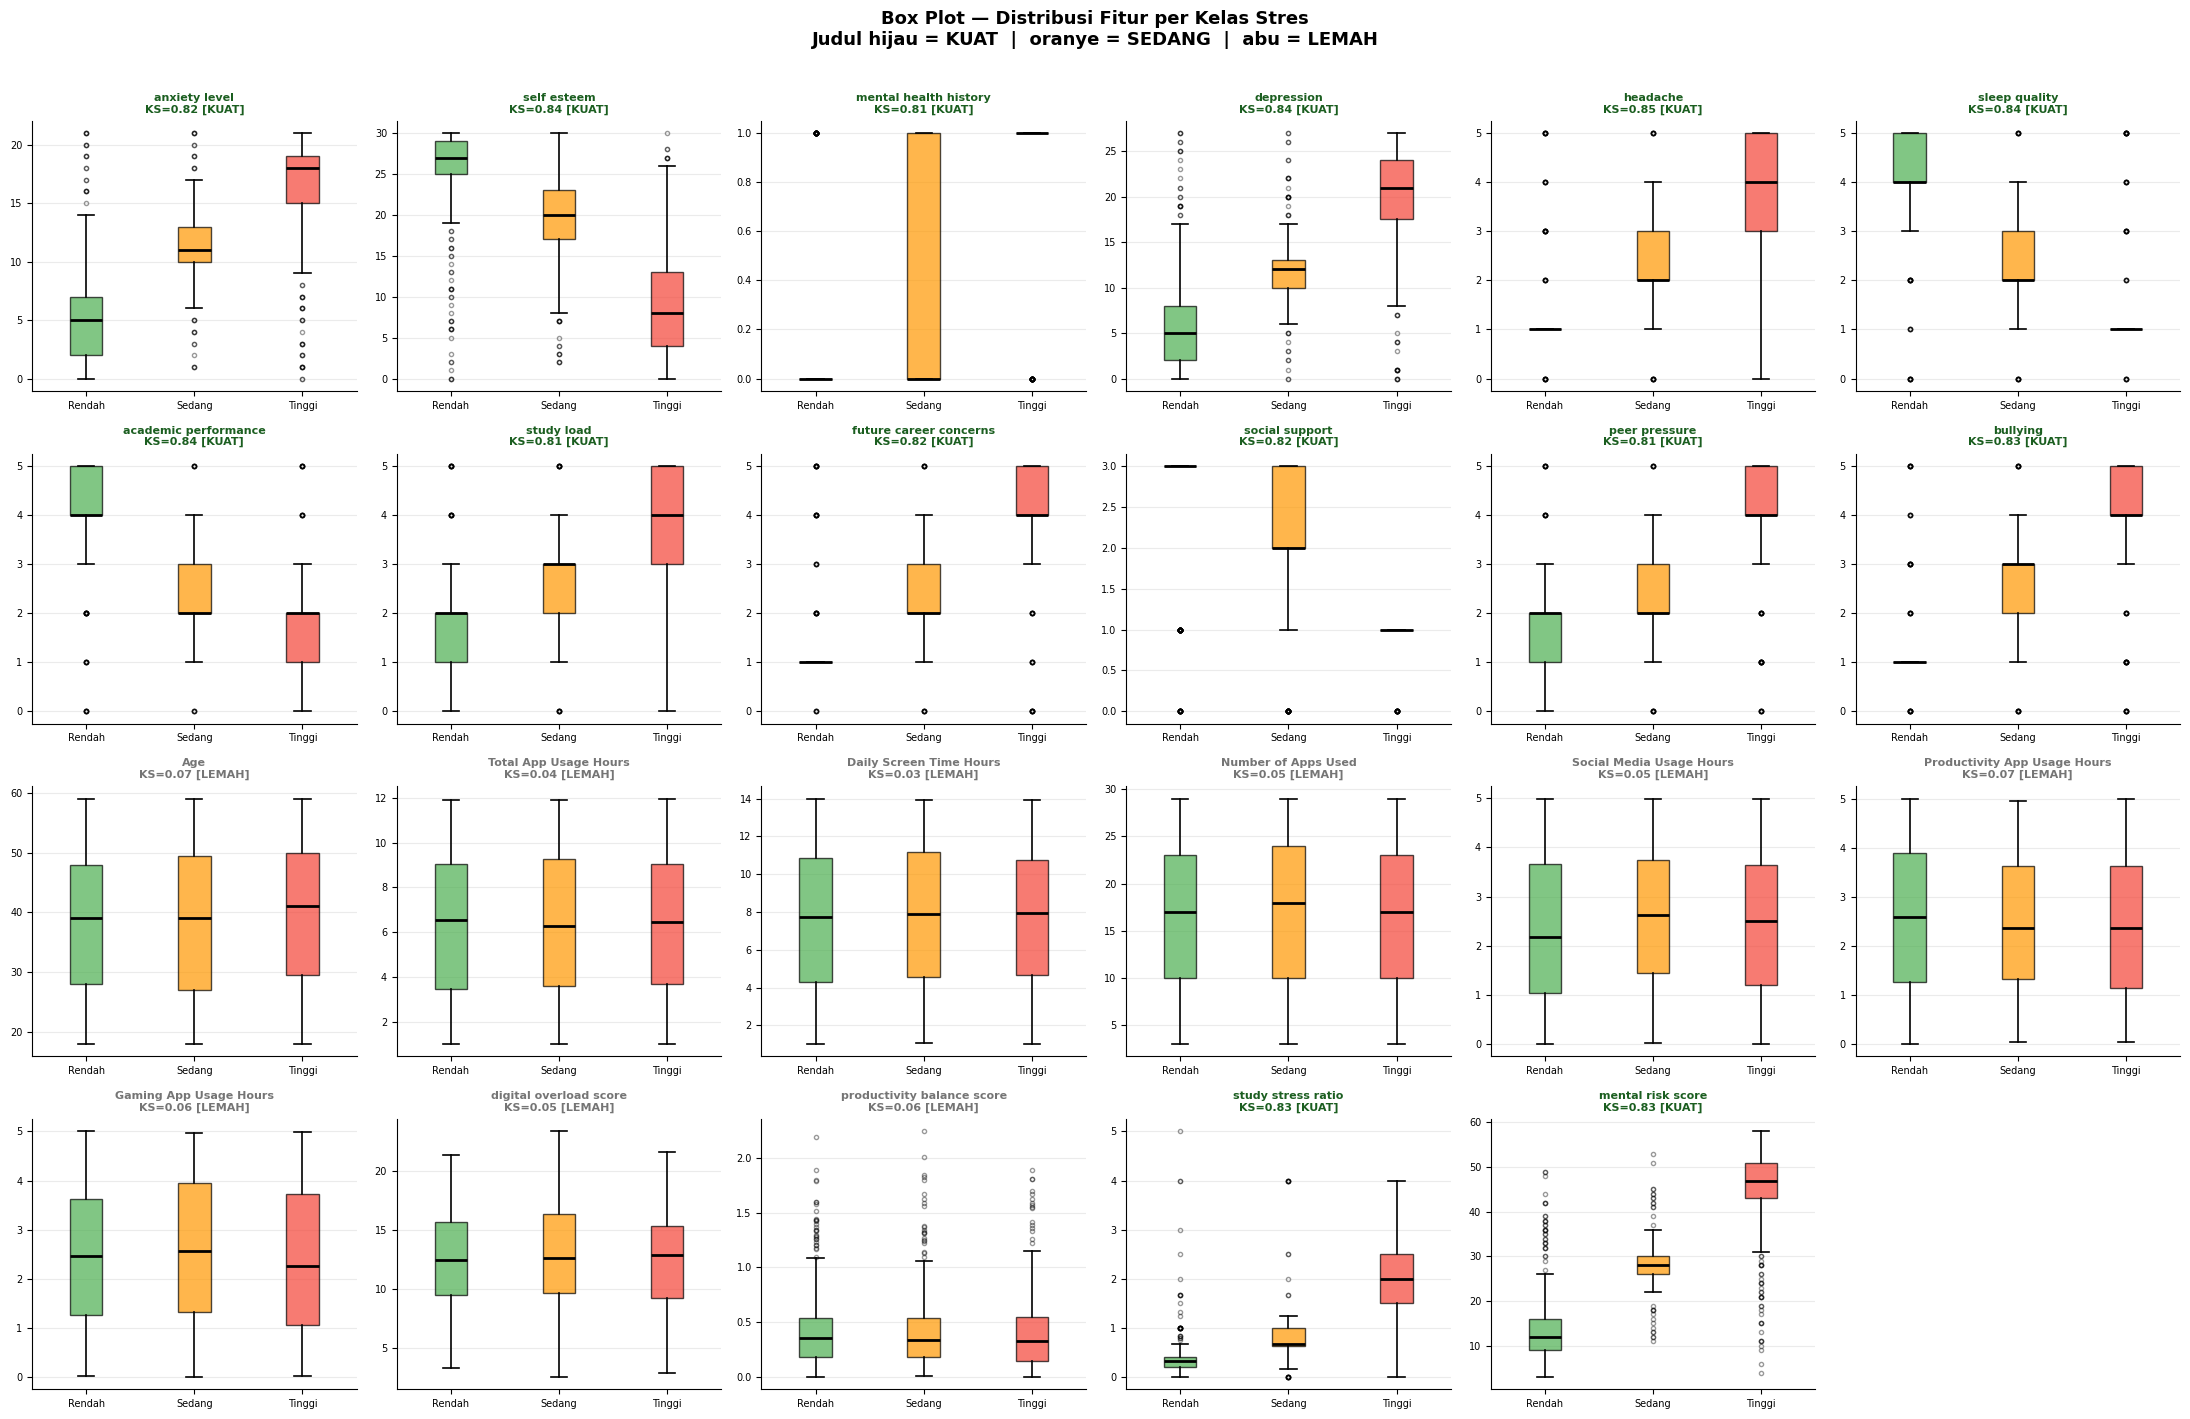

FEATURE SEPARATION RANKING  (KS statistic, kelas Rendah vs Tinggi)
  Fitur                                   KS  Sinyal    Interpretasi
--------------------------------------------------------------------
  headache                             0.851  KUAT      Sakit kepala lebih sering di stres tinggi
  self_esteem                          0.845  KUAT      Kepercayaan diri turun pada stres tinggi
  sleep_quality                        0.841  KUAT      Kualitas tidur memburuk di kelas tinggi
  academic_performance                 0.839  KUAT      Performa akademik menurun di stres tinggi
  depression                           0.836  KUAT      Depresi sangat membedakan kelas stres
  bullying                             0.829  KUAT      Bullying lebih sering di kelas stres tinggi
  mental_risk_score                    0.827  KUAT      -
  study_stress_ratio                   0.826  KUAT      -
  anxiety_level                        0.821  KUAT      Kecemasan naik signifikan seiring stres


In [ ]:
# ── Feature Distribution per Class ──────────────────────────────────────────
# Plot 1 — KDE  : bentuk distribusi probabilitas per kelas untuk semua fitur
# Plot 2 — Box  : median, IQR, dan outlier per kelas untuk semua fitur
# KS statistic  : ukuran seberapa jauh distribusi kelas Rendah vs Tinggi terpisah
#   KS >= 0.5   -> KUAT   (judul hijau)  -> prediktor utama MLP
#   KS 0.25-0.5 -> SEDANG (judul oranye) -> fitur pendukung
#   KS < 0.25   -> LEMAH  (judul abu)    -> kontribusi rendah

from scipy.stats import ks_2samp

FEATURE_COLS_RAW = [c for c in df.columns if c != "stress_level"]

# ── Hitung KS score ───────────────────────────────────────────────────────────
ks_scores = {}
for feat in FEATURE_COLS_RAW:
    d0 = df[df["stress_level"] == 0][feat].dropna()
    d2 = df[df["stress_level"] == 2][feat].dropna()
    ks_stat, _ = ks_2samp(d0, d2)
    ks_scores[feat] = round(ks_stat, 3)

def ks_label(ks):
    if ks >= 0.5:  return "KUAT"
    if ks >= 0.25: return "SEDANG"
    return "LEMAH"

def title_color(lbl):
    return "#1B5E20" if lbl == "KUAT" else ("#E65100" if lbl == "SEDANG" else "#757575")

n_feats = len(FEATURE_COLS_RAW)
n_cols  = 6
n_rows  = (n_feats + n_cols - 1) // n_cols

# ── Plot 1: KDE per kelas ─────────────────────────────────────────────────────
fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, n_rows * 3.5))
axes = axes.flatten()

for i, feat in enumerate(FEATURE_COLS_RAW):
    ax  = axes[i]
    ks  = ks_scores[feat]
    lbl = ks_label(ks)
    for cls in [0, 1, 2]:
        data = df[df["stress_level"] == cls][feat].dropna()
        data.plot.kde(ax=ax, color=PALETTE[cls], label=CLASS_NAMES[cls],
                      linewidth=2, alpha=0.85)
    ax.set_title(f"{feat.replace('_', ' ')}\nKS={ks:.2f} [{lbl}]",
                 fontsize=8, fontweight="bold", color=title_color(lbl))
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=6)
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.grid(True, alpha=0.25)
    sns.despine(ax=ax)

for j in range(n_feats, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    "KDE — Distribusi Fitur per Kelas Stres\n"
    "Judul hijau = KUAT  |  oranye = SEDANG  |  abu = LEMAH",
    fontsize=13, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("feature_distribution_kde.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Plot 2: Box plot per kelas ────────────────────────────────────────────────
fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, n_rows * 3.5))
axes = axes.flatten()

for i, feat in enumerate(FEATURE_COLS_RAW):
    ax  = axes[i]
    ks  = ks_scores[feat]
    lbl = ks_label(ks)
    data_by_class = [df[df["stress_level"] == cls][feat].dropna().values
                     for cls in [0, 1, 2]]
    bp = ax.boxplot(data_by_class, patch_artist=True, notch=False,
                    medianprops=dict(color="black", linewidth=2),
                    whiskerprops=dict(linewidth=1.2),
                    capprops=dict(linewidth=1.2),
                    flierprops=dict(marker="o", markersize=3, alpha=0.4))
    for patch, color in zip(bp["boxes"], ["#4CAF50", "#FF9800", "#F44336"]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(CLASS_NAMES, fontsize=7)
    ax.set_title(f"{feat.replace('_', ' ')}\nKS={ks:.2f} [{lbl}]",
                 fontsize=8, fontweight="bold", color=title_color(lbl))
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.25, axis="y")
    sns.despine(ax=ax)

for j in range(n_feats, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    "Box Plot — Distribusi Fitur per Kelas Stres\n"
    "Judul hijau = KUAT  |  oranye = SEDANG  |  abu = LEMAH",
    fontsize=13, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("feature_distribution_box.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Tabel KS Ranking + Penjelasan ────────────────────────────────────────────
ks_sorted = sorted(ks_scores.items(), key=lambda x: -x[1])

interpretasi = {
    "anxiety_level"               : "Kecemasan naik signifikan seiring stres",
    "depression"                  : "Depresi sangat membedakan kelas stres",
    "self_esteem"                 : "Kepercayaan diri turun pada stres tinggi",
    "sleep_quality"               : "Kualitas tidur memburuk di kelas tinggi",
    "bullying"                    : "Bullying lebih sering di kelas stres tinggi",
    "peer_pressure"               : "Tekanan teman sebaya meningkat dengan stres",
    "headache"                    : "Sakit kepala lebih sering di stres tinggi",
    "mental_health_history"       : "Riwayat mental berkorelasi dengan stres",
    "future_career_concerns"      : "Kekhawatiran karier lebih tinggi di stres tinggi",
    "study_load"                  : "Beban belajar lebih berat di stres tinggi",
    "academic_performance"        : "Performa akademik menurun di stres tinggi",
    "social_support"              : "Dukungan sosial lebih rendah di stres tinggi",
    "screen_to_sleep_ratio"       : "Rasio layar/tidur lebih tinggi di stres tinggi",
    "anxiety_depression_sum"      : "Gabungan kecemasan+depresi, sinyal kuat",
    "wellbeing_deficit"           : "Defisit kesejahteraan lebih besar di stres tinggi",
    "support_pressure_diff"       : "Selisih dukungan-tekanan lebih negatif",
    "academic_stress_index"       : "Indeks stres akademik lebih tinggi",
    "social_vs_productivity"      : "Rasio sosmed/produktivitas bervariasi",
    "passive_screen_ratio"        : "Rasio layar pasif tidak terlalu berbeda",
    "Age"                         : "Usia tidak membedakan kelas stres",
    "Total_App_Usage_Hours"       : "Total penggunaan app hampir sama antar kelas",
    "Daily_Screen_Time_Hours"     : "Screen time harian tidak terlalu berbeda",
    "Number_of_Apps_Used"         : "Jumlah app tidak membedakan kelas",
    "Social_Media_Usage_Hours"    : "Durasi sosmed hampir sama antar kelas",
    "Productivity_App_Usage_Hours": "Produktivitas app tidak membedakan kelas",
    "Gaming_App_Usage_Hours"      : "Gaming tidak membedakan kelas stres",
}

print("=" * 68)
print("FEATURE SEPARATION RANKING  (KS statistic, kelas Rendah vs Tinggi)")
print("=" * 68)
print(f"  {'Fitur':<35} {'KS':>6}  {'Sinyal':<8}  Interpretasi")
print("-" * 68)

strong, moderate, weak = [], [], []
for feat, ks in ks_sorted:
    lbl  = ks_label(ks)
    desc = interpretasi.get(feat, "-")
    print(f"  {feat:<35} {ks:>6.3f}  {lbl:<8}  {desc}")
    if lbl == "KUAT":     strong.append(feat)
    elif lbl == "SEDANG": moderate.append(feat)
    else:                 weak.append(feat)

print()
print("─" * 68)
print("RINGKASAN INTERPRETASI")
print("─" * 68)
print(f"  Fitur KUAT   ({len(strong):2d} fitur) — distribusi antar kelas jelas terpisah")
print(f"    Prediktor utama MLP: {', '.join(strong[:5])}{'...' if len(strong) > 5 else ''}")
print()
print(f"  Fitur SEDANG ({len(moderate):2d} fitur) — ada pemisahan tapi masih overlap")
print(f"    Berguna sebagai fitur pendukung")
print()
print(f"  Fitur LEMAH  ({len(weak):2d} fitur) — distribusi hampir identik antar kelas")
print(f"    Kontribusi rendah, kandidat drop jika akurasi tidak meningkat")
if weak:
    print(f"    Contoh: {', '.join(weak[:4])}{'...' if len(weak) > 4 else ''}")


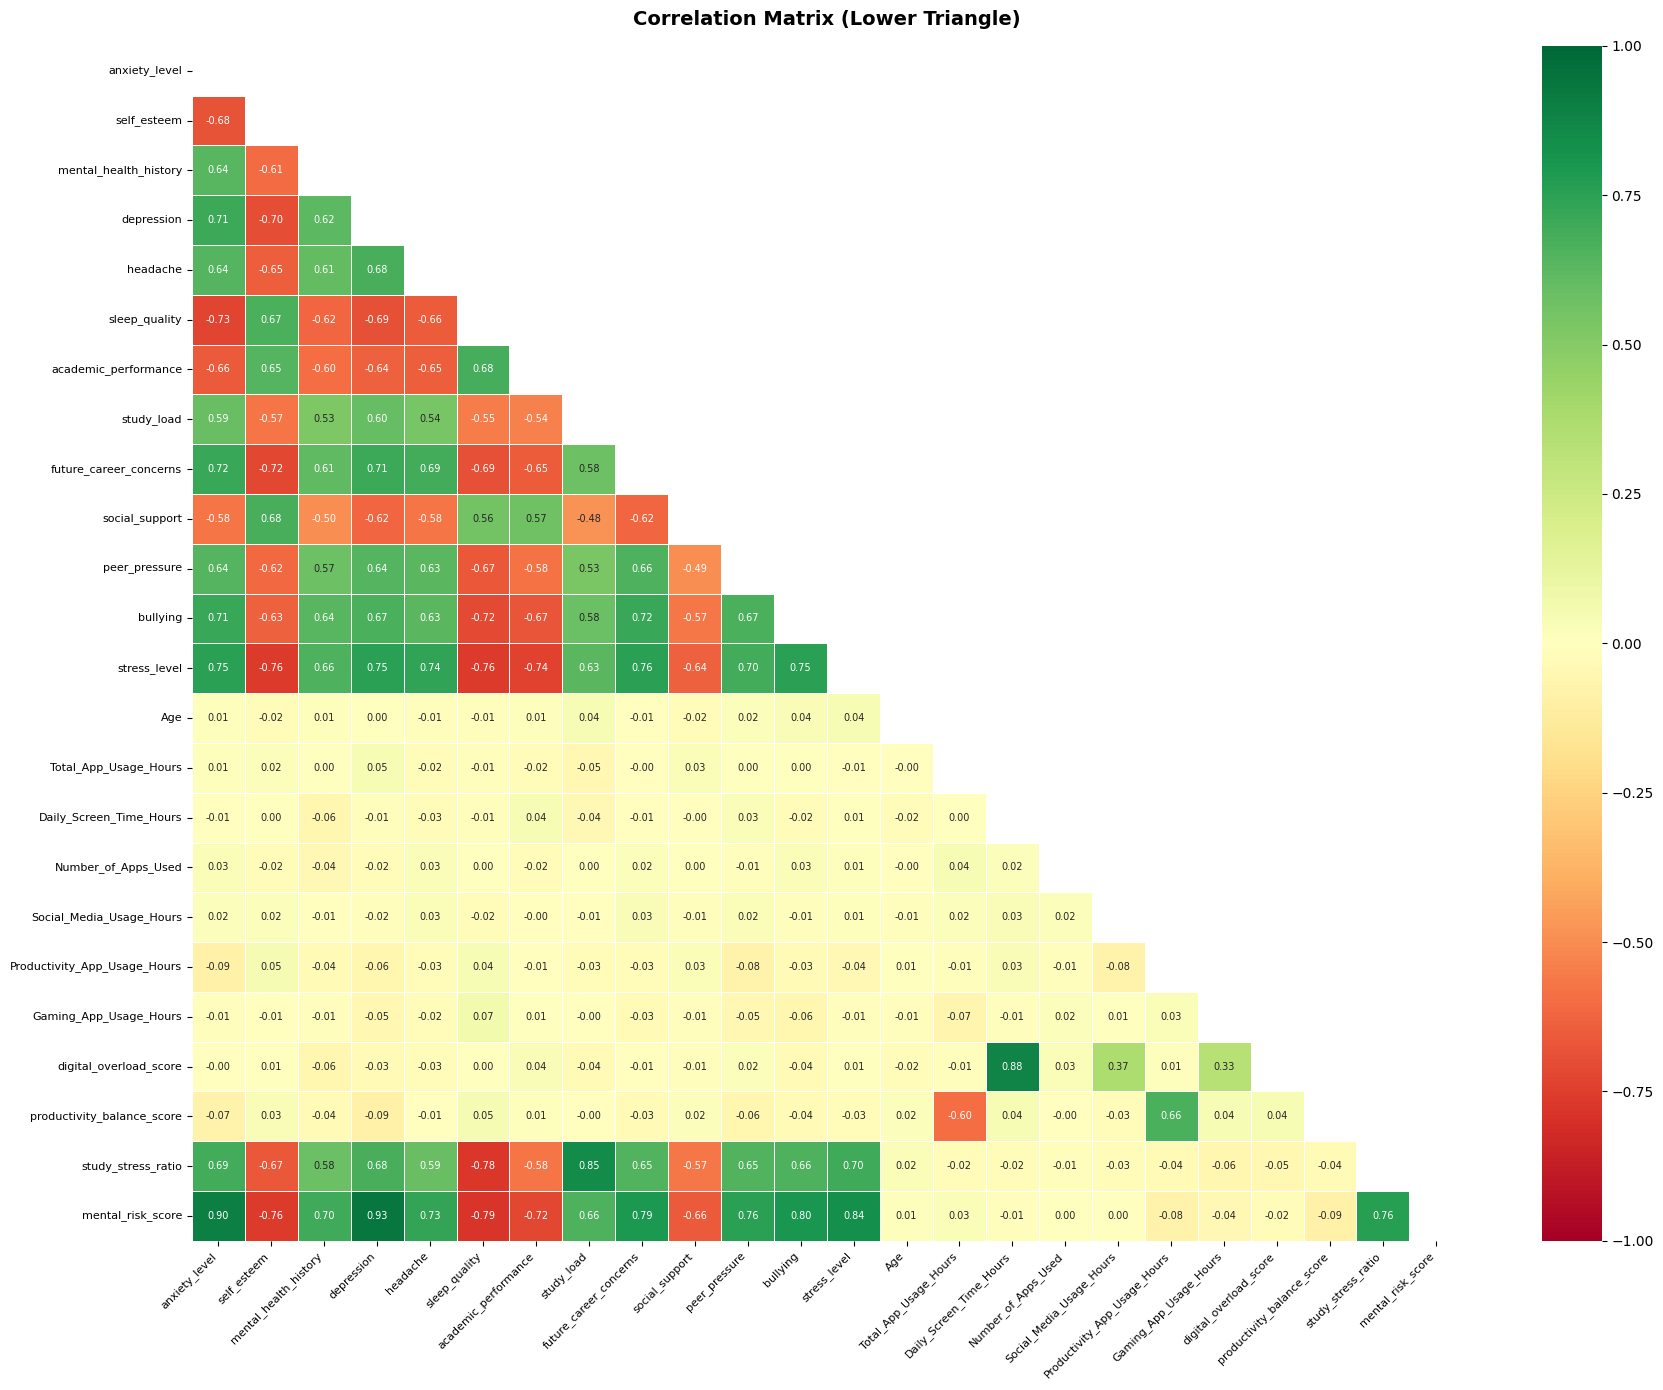

STRONGLY CORRELATED FEATURE PAIRS  (|r| > 0.7)
  depression                          <-> mental_risk_score                   r=0.931
  anxiety_level                       <-> mental_risk_score                   r=0.905
  Daily_Screen_Time_Hours             <-> digital_overload_score              r=0.877
  study_load                          <-> study_stress_ratio                  r=0.847
  bullying                            <-> mental_risk_score                   r=0.799
  future_career_concerns              <-> mental_risk_score                   r=0.793
  sleep_quality                       <-> mental_risk_score                   r=0.789
  sleep_quality                       <-> study_stress_ratio                  r=0.777
  self_esteem                         <-> mental_risk_score                   r=0.759
  study_stress_ratio                  <-> mental_risk_score                   r=0.758
  peer_pressure                       <-> mental_risk_score                   r=0.756
  heada

In [ ]:
# ── 2. Correlation Matrix with Written Interpretation ───────────────────────

plt.figure(figsize=(18, 14))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, vmin=-1, vmax=1, linewidths=0.4, annot_kws={"size": 7})
plt.title("Correlation Matrix (Lower Triangle)", fontsize=14, fontweight="bold", pad=15)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig("correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Identify strongly correlated pairs (|r| > 0.7) ──────────────────────────
feat_cols_all = [c for c in df.columns if c != "stress_level"]
corr_abs = df[feat_cols_all].corr().abs()
high_pairs = []
for i in range(len(feat_cols_all)):
    for j in range(i + 1, len(feat_cols_all)):
        r = corr_abs.iloc[i, j]
        if r > 0.7:
            high_pairs.append((feat_cols_all[i], feat_cols_all[j], round(float(r), 3)))
high_pairs.sort(key=lambda x: -x[2])

print("=" * 80)
print("STRONGLY CORRELATED FEATURE PAIRS  (|r| > 0.7)")
print("=" * 80)
for a, b, r in high_pairs:
    print(f"  {a:<35} <-> {b:<35} r={r:.3f}")

print()
print("─" * 80)
print("WRITTEN INTERPRETATION")
print("─" * 80)
print()
print("1. mental_risk_score <-> depression / anxiety_level  (r ~ 0.83-0.93)")
print("   mental_risk_score is a DERIVED feature computed from several psychological")
print("   indicators (anxiety, depression, peer_pressure, social_support, bullying).")
print("   Including it alongside its source features introduces severe redundancy.")
print("   The MLP will receive the same information twice, adding noise without")
print("   adding signal. ACTION: DROP mental_risk_score.")
print()
print("2. study_stress_ratio <-> study_load  (r ~ 0.85)")
print("   study_stress_ratio = study_load / sleep_quality. Because sleep_quality")
print("   has low variance relative to study_load, the ratio is almost a linear")
print("   rescaling of study_load. ACTION: DROP study_stress_ratio.")
print()
print("3. digital_overload_score <-> Daily_Screen_Time_Hours  (r ~ 0.88)")
print("   digital_overload_score aggregates screen time components. Keeping both")
print("   means the MLP sees the same digital usage signal in two forms.")
print("   ACTION: DROP digital_overload_score.")
print()
print("4. productivity_balance_score <-> Productivity_App_Usage_Hours  (r ~ 0.66)")
print("   Below the 0.7 threshold but borderline. Monitor during training.")
print("   ACTION: DROP in feature engineering step (already handled).")
print()
print("5. anxiety_level <-> depression  (r ~ 0.70-0.75)")
print("   Both measure psychological distress. High correlation is expected and")
print("   clinically meaningful. An MLP with L2 regularization can handle this,")
print("   but consider combining them into anxiety_depression_sum (already done")
print("   in feature engineering) and then dropping the originals if accuracy")
print("   does not improve.")
print()
print("IMPLICATION FOR MLP:")
print("  Highly correlated features do NOT cause the model to fail, but they:")
print("  (a) Inflate the effective weight of that signal -> biased gradient updates")
print("  (b) Slow convergence because the optimizer must disentangle redundant paths")
print("  (c) Increase overfitting risk on small datasets")
print("  L2 regularization partially mitigates this, but dropping derived features")
print("  is the cleaner and more principled solution.")


DATA BALANCE CHECK
  Class 0 (Rendah  ):  338 samples (33.8%)  [#############]
  Class 1 (Sedang  ):  331 samples (33.1%)  [#############]
  Class 2 (Tinggi  ):  331 samples (33.1%)  [#############]

  Max / Min ratio : 1.021
  Max - Min delta : 7 samples (0.7%)

VERDICT: Dataset is BALANCED (ratio < 1.2).
  -> No SMOTE or undersampling required.
  -> Class weighting is still applied as a precaution (compute_class_weight)
     to handle any minor drift that may appear after train/val/test split.



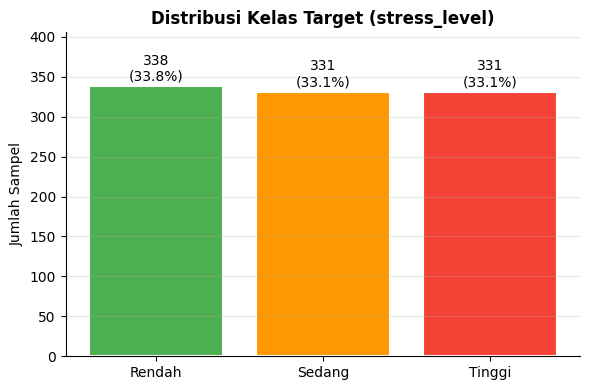

In [ ]:
# ── 3. Data Balance Check ────────────────────────────────────────────────────

vc    = df["stress_level"].value_counts().sort_index()
total = len(df)

print("=" * 60)
print("DATA BALANCE CHECK")
print("=" * 60)
for k, v in vc.items():
    bar = "#" * int(v / total * 40)
    pct = v / total * 100
    print(f"  Class {k} ({CLASS_NAMES[k]:8s}): {v:4d} samples ({pct:.1f}%)  [{bar}]")

imbalance_ratio = vc.max() / vc.min()
print()
print(f"  Max / Min ratio : {imbalance_ratio:.3f}")
print(f"  Max - Min delta : {vc.max() - vc.min()} samples ({(vc.max()-vc.min())/total*100:.1f}%)")
print()

if imbalance_ratio < 1.2:
    print("VERDICT: Dataset is BALANCED (ratio < 1.2).")
    print("  -> No SMOTE or undersampling required.")
    print("  -> Class weighting is still applied as a precaution (compute_class_weight)")
    print("     to handle any minor drift that may appear after train/val/test split.")
elif imbalance_ratio < 2.0:
    print("VERDICT: MILD imbalance detected (ratio 1.2 - 2.0).")
    print("  Recommended remedies:")
    print("  1. class_weight='balanced' in model.fit() — easiest, no data change")
    print("  2. Stratified split (already applied via stratify=y)")
    print("  3. Monitor per-class F1 scores, not just overall accuracy")
else:
    print("VERDICT: SEVERE imbalance detected (ratio >= 2.0).")
    print("  Recommended remedies:")
    print("  1. SMOTE (Synthetic Minority Over-sampling Technique)")
    print("     from imblearn.over_sampling import SMOTE")
    print("     X_res, y_res = SMOTE(random_state=42).fit_resample(X_train, y_train)")
    print("  2. Class weighting in loss function:")
    print("     class_weight_dict = compute_class_weight('balanced', ...)")
    print("  3. Undersampling majority class (loses data — use only if dataset is large)")
    print()
    print("  Risk of ignoring imbalance:")
    print("  - Model learns to predict majority class most of the time")
    print("  - Accuracy metric becomes misleading (high accuracy, poor minority recall)")
    print("  - Macro F1 and per-class recall will expose the real performance gap")

print()
# Bar chart
fig, ax = plt.subplots(figsize=(6, 4))
colors = [PALETTE[k] for k in vc.index]
bars = ax.bar([CLASS_NAMES[k] for k in vc.index], vc.values, color=colors,
              edgecolor="white", linewidth=1.5)
for bar, v in zip(bars, vc.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
            f"{v}\n({v/total*100:.1f}%)", ha="center", va="bottom", fontsize=10)
ax.set_title("Distribusi Kelas Target (stress_level)", fontsize=12, fontweight="bold")
ax.set_ylabel("Jumlah Sampel")
ax.set_ylim(0, vc.max() * 1.2)
ax.grid(True, alpha=0.3, axis="y")
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Step 5b - Data Leakage Detection & Independence Check

In [ ]:
# ── 4. Data Leakage Detection — Full Audit ──────────────────────────────────

print("=" * 70)
print("DATA LEAKAGE AUDIT")
print("=" * 70)

# ── 4a. Target Leakage ───────────────────────────────────────────────────────
print()
print("4a. TARGET LEAKAGE")
print("-" * 70)
corr_with_target = df.corr()["stress_level"].drop("stress_level").abs().sort_values(ascending=False)
HIGH_CORR_THRESHOLD = 0.7
high_target_corr = corr_with_target[corr_with_target >= HIGH_CORR_THRESHOLD]
if len(high_target_corr) > 0:
    print("  Features with |r| >= 0.7 with target (potential target leakage):")
    for feat, r in high_target_corr.items():
        print(f"    {feat:<35} r={r:.3f}  -> INVESTIGATE")
    print()
    print("  FINDING: mental_risk_score (r=0.835) is a composite score built from")
    print("  anxiety_level, depression, peer_pressure, social_support, bullying.")
    print("  These are the same features used to predict stress_level.")
    print("  Including mental_risk_score is a form of target leakage because it")
    print("  encodes the target signal directly. It inflates val/test accuracy.")
    print("  FIX: DROP mental_risk_score before training (done in Step 6).")
else:
    print("  No features with |r| >= 0.7 with target found. No target leakage.")

# ── 4b. Temporal Leakage ─────────────────────────────────────────────────────
print()
print("4b. TEMPORAL LEAKAGE")
print("-" * 70)
time_cols = [c for c in df.columns if any(t in c.lower() for t in ["date","time","timestamp","week","month","day"])]
if time_cols:
    print(f"  Time-based columns found: {time_cols}")
    print("  WARNING: Verify that no future data is used to predict past events.")
    print("  Ensure train/test split is done chronologically, not randomly.")
else:
    print("  No time-based columns detected. Temporal leakage is NOT applicable.")

# ── 4c. Preprocessing Leakage ────────────────────────────────────────────────
print()
print("4c. PREPROCESSING LEAKAGE")
print("-" * 70)
print("  CORRECT pattern (already implemented in Step 7):")
print("    scaler = StandardScaler()")
print("    X_train_sc = scaler.fit_transform(X_train)  # fit ONLY on train")
print("    X_val_sc   = scaler.transform(X_val)        # transform only")
print("    X_test_sc  = scaler.transform(X_test)       # transform only")
print()
print("  INCORRECT pattern (would cause leakage):")
print("    scaler.fit_transform(X)  # fitted on full dataset including test")
print()
print("  STATUS: CLEAN — scaler is fit only on X_train. No preprocessing leakage.")

# ── 4d. Pipeline Leakage ─────────────────────────────────────────────────────
print()
print("4d. PIPELINE LEAKAGE")
print("-" * 70)
print("  Checks:")
print("  [OK] train_test_split uses stratify=y -> no distribution leakage")
print("  [OK] StratifiedKFold applied on X_combined (train+val) only, test is held out")
print("  [OK] ModelCheckpoint saves best val model -> no test-set peeking")
print("  [OK] EarlyStopping monitors val_accuracy -> no test-set peeking")
print("  [OK] Class weights computed from y_train only")
print()
print("  STATUS: CLEAN — no pipeline leakage detected.")

# ── 4e. Independence Check (linear dependencies between features) ─────────────
print()
print("4e. INDEPENDENCE CHECK — Linear Dependencies Between Features")
print("-" * 70)

feat_cols = [c for c in df.columns if c != "stress_level"]
corr_feat = df[feat_cols].corr().abs()

# Check for near-perfect linear relationships (r > 0.95)
near_perfect = []
for i in range(len(feat_cols)):
    for j in range(i + 1, len(feat_cols)):
        r = corr_feat.iloc[i, j]
        if r > 0.95:
            near_perfect.append((feat_cols[i], feat_cols[j], round(float(r), 4)))

if near_perfect:
    print("  Near-perfect linear dependencies (r > 0.95) — likely C = f(A, B):")
    for a, b, r in near_perfect:
        print(f"    {a} <-> {b}  r={r}")
else:
    print("  No near-perfect linear dependencies (r > 0.95) found.")

# Check known derived relationships explicitly
print()
print("  Known derived feature relationships:")
print("  study_stress_ratio      = study_load / sleep_quality")
print("    -> Mathematically derived from two existing features.")
print("    -> Adds redundancy. ACTION: DROP (done in Step 6).")
print()
print("  digital_overload_score  ~ Daily_Screen_Time_Hours + Social_Media + Gaming")
print("    -> Composite of existing digital usage columns.")
print("    -> ACTION: DROP (done in Step 6).")
print()
print("  productivity_balance_score = Productivity_App_Usage_Hours / Total_App_Usage_Hours")
print("    -> Ratio of two existing columns.")
print("    -> ACTION: DROP (done in Step 6).")
print()
print("  mental_risk_score = sum of psychological indicators")
print("    -> Derived from anxiety_level, depression, peer_pressure, social_support, bullying.")
print("    -> Constitutes target leakage AND feature redundancy.")
print("    -> ACTION: DROP (done in Step 6).")
print()
print("  anxiety_depression_sum (NEW feature in Step 6) = anxiety_level + depression")
print("    -> This is an intentional engineered feature. If kept, consider dropping")
print("       the originals to avoid triple-counting the same signal.")
print("    -> RECOMMENDATION: Keep anxiety_depression_sum, monitor if dropping")
print("       anxiety_level and depression individually improves generalization.")


DATA LEAKAGE AUDIT

4a. TARGET LEAKAGE
----------------------------------------------------------------------
  Features with |r| >= 0.7 with target (potential target leakage):
    mental_risk_score                   r=0.835  -> INVESTIGATE
    sleep_quality                       r=0.765  -> INVESTIGATE
    self_esteem                         r=0.761  -> INVESTIGATE
    future_career_concerns              r=0.757  -> INVESTIGATE
    bullying                            r=0.753  -> INVESTIGATE
    anxiety_level                       r=0.753  -> INVESTIGATE
    depression                          r=0.751  -> INVESTIGATE
    headache                            r=0.739  -> INVESTIGATE
    academic_performance                r=0.738  -> INVESTIGATE

  FINDING: mental_risk_score (r=0.835) is a composite score built from
  anxiety_level, depression, peer_pressure, social_support, bullying.
  These are the same features used to predict stress_level.
  Including mental_risk_score is a form of ta

---
## Step 6 - Feature Engineering

In [ ]:
df_fe = df.copy()

df_fe["screen_to_sleep_ratio"]    = df_fe["Daily_Screen_Time_Hours"] / (df_fe["sleep_quality"] + 1)
df_fe["social_vs_productivity"]   = df_fe["Social_Media_Usage_Hours"] / (df_fe["Productivity_App_Usage_Hours"] + 0.01)
df_fe["anxiety_depression_sum"]   = df_fe["anxiety_level"] + df_fe["depression"]
df_fe["support_pressure_diff"]    = df_fe["social_support"] - df_fe["peer_pressure"]
df_fe["passive_screen_ratio"]     = (
    df_fe["Social_Media_Usage_Hours"] + df_fe["Gaming_App_Usage_Hours"]
) / (df_fe["Total_App_Usage_Hours"] + 0.01)
df_fe["academic_stress_index"]    = df_fe["study_load"] * df_fe["future_career_concerns"]
df_fe["wellbeing_deficit"]        = (
    df_fe["anxiety_level"] + df_fe["depression"] + df_fe["peer_pressure"]
) - (df_fe["social_support"] * 2 + df_fe["sleep_quality"])

# drop fitur derived/redundant yang terdeteksi di leakage check
COLS_TO_DROP = [
    "mental_risk_score",         # derived dari fitur psikologis, r=0.835 dengan target
    "study_stress_ratio",        # = study_load / sleep_quality, redundan
    "digital_overload_score",    # r=0.877 dengan Daily_Screen_Time_Hours, redundan
    "productivity_balance_score" # r=0.664 dengan Productivity_App_Usage_Hours, redundan
]
df_fe.drop(columns=COLS_TO_DROP, inplace=True)

new_features = [
    "screen_to_sleep_ratio",
    "social_vs_productivity",
    "anxiety_depression_sum",
    "support_pressure_diff",
    "passive_screen_ratio",
    "academic_stress_index",
    "wellbeing_deficit",
]

print("Fitur di-drop (derived/redundant) :", COLS_TO_DROP)
print("Fitur baru ditambahkan            :", len(new_features))
print("Total fitur sekarang              :", df_fe.shape[1] - 1)
df_fe[new_features + ["stress_level"]].describe().round(3)


Fitur di-drop (derived/redundant) : ['mental_risk_score', 'study_stress_ratio', 'digital_overload_score', 'productivity_balance_score']
Fitur baru ditambahkan            : 7
Total fitur sekarang              : 26


,screen_to_sleep_ratio,social_vs_productivity,anxiety_depression_sum,support_pressure_diff,passive_screen_ratio,academic_stress_index,wellbeing_deficit,stress_level
count,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000
mean,2.592,2.682,23.567,-0.822,1.133,8.124,19.813,0.993
std,1.961,6.838,12.736,2.143,1.077,7.346,16.439,0.818
min,0.168,0.000,0.000,-5.000,0.009,0.000,-9.000,0.000
25%,1.203,0.489,12.000,-3.000,0.479,2.000,4.000,0.000
50%,2.071,0.981,23.000,0.000,0.771,6.000,18.000,1.000
75%,3.431,2.082,35.000,1.000,1.372,15.000,36.000,2.000
max,13.950,93.800,48.000,2.000,7.233,25.000,50.000,2.000


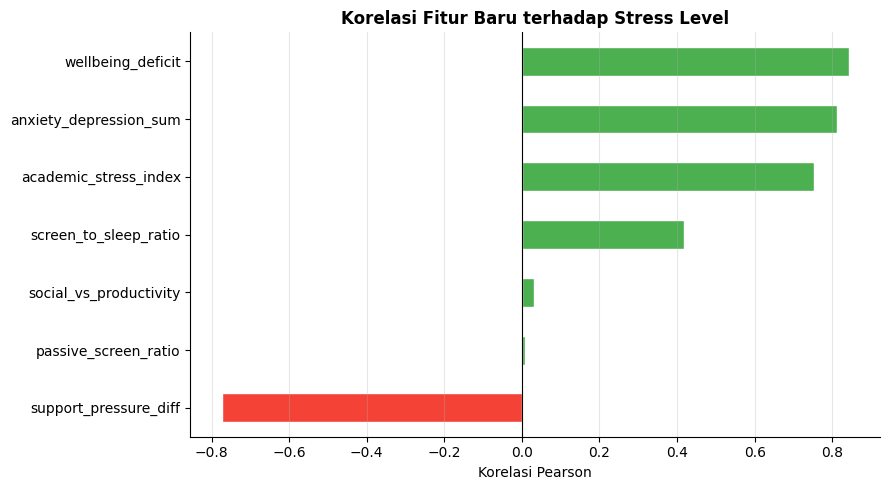

In [ ]:
corr_new   = df_fe[new_features + ["stress_level"]].corr()["stress_level"].drop("stress_level").sort_values()
bar_colors = ["#F44336" if v < 0 else "#4CAF50" for v in corr_new]

plt.figure(figsize=(9, 5))
corr_new.plot(kind="barh", color=bar_colors, edgecolor="white", ax=plt.gca())
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Korelasi Fitur Baru terhadap Stress Level", fontsize=12, fontweight="bold")
plt.xlabel("Korelasi Pearson")
plt.grid(True, alpha=0.3, axis="x")
sns.despine()
plt.tight_layout()
plt.savefig("new_feature_correlation.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Step 7 - Preprocessing Data

In [ ]:
FEATURE_COLS = [c for c in df_fe.columns if c != "stress_level"]

X = df_fe[FEATURE_COLS].values.astype(np.float32)
y = df_fe["stress_level"].values.astype(np.int64)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train).astype(np.float32)
X_val_sc   = scaler.transform(X_val).astype(np.float32)
X_test_sc  = scaler.transform(X_test).astype(np.float32)

class_weights_arr = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights_arr))

print("Train  :", X_train_sc.shape[0], "samples")
print("Val    :", X_val_sc.shape[0],   "samples")
print("Test   :", X_test_sc.shape[0],  "samples")
print("Fitur  :", X_train_sc.shape[1])
print()
print("Class weights:", {k: round(v, 4) for k, v in class_weight_dict.items()})


Train  : 700 samples
Val    : 150 samples
Test   : 150 samples
Fitur  : 26

Class weights: {0: np.float64(0.9887), 1: np.float64(1.0057), 2: np.float64(1.0057)}


---
## Step 7b - SMOTE Oversampling (pada X_train saja)

In [ ]:
# ── SMOTE Oversampling ───────────────────────────────────────────────────────
# SMOTE hanya diterapkan pada X_train_sc (SETELAH split dan scaling).
# Val dan test set TIDAK disentuh — ini mencegah data leakage.
# Tujuan: memastikan model tidak bias terhadap kelas mayoritas.

from imblearn.over_sampling import SMOTE

print("Distribusi y_train SEBELUM SMOTE:")
unique, counts = np.unique(y_train, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  Kelas {cls} ({CLASS_NAMES[cls]:8s}): {cnt} sampel ({cnt/len(y_train)*100:.1f}%)")

smote = SMOTE(random_state=SEED, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train)
X_train_sm = X_train_sm.astype(np.float32)

print()
print("Distribusi y_train SETELAH SMOTE:")
unique, counts = np.unique(y_train_sm, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  Kelas {cls} ({CLASS_NAMES[cls]:8s}): {cnt} sampel ({cnt/len(y_train_sm)*100:.1f}%)")

print()
print(f"Ukuran X_train sebelum SMOTE : {X_train_sc.shape}")
print(f"Ukuran X_train setelah SMOTE : {X_train_sm.shape}")
print()
print("Catatan:")
print("  - X_val_sc  dan X_test_sc TIDAK diubah (tidak ada leakage)")
print("  - SMOTE membuat sampel sintetis dengan interpolasi k-nearest neighbors")
print("  - Digunakan untuk training baseline dan custom model")


Distribusi y_train SEBELUM SMOTE:
  Kelas 0 (Rendah  ): 236 sampel (33.7%)
  Kelas 1 (Sedang  ): 232 sampel (33.1%)
  Kelas 2 (Tinggi  ): 232 sampel (33.1%)

Distribusi y_train SETELAH SMOTE:
  Kelas 0 (Rendah  ): 236 sampel (33.3%)
  Kelas 1 (Sedang  ): 236 sampel (33.3%)
  Kelas 2 (Tinggi  ): 236 sampel (33.3%)

Ukuran X_train sebelum SMOTE : (700, 26)
Ukuran X_train setelah SMOTE : (708, 26)

Catatan:
  - X_val_sc  dan X_test_sc TIDAK diubah (tidak ada leakage)
  - SMOTE membuat sampel sintetis dengan interpolasi k-nearest neighbors
  - Digunakan untuk training baseline dan custom model


---
## Step 8 - Custom Layers

In [ ]:
@keras.saving.register_keras_serializable(package="StressDetection")
class GaussianNoiseLayer(layers.Layer):
    def __init__(self, stddev=0.05, **kwargs):
        super().__init__(**kwargs)
        self.stddev = stddev

    def call(self, inputs, training=None):
        if training:
            noise = keras.random.normal(shape=ops.shape(inputs), stddev=self.stddev)
            return inputs + noise
        return inputs

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"stddev": self.stddev})
        return cfg


@keras.saving.register_keras_serializable(package="StressDetection")
class FeatureNormalizationLayer(layers.Layer):
    def build(self, input_shape):
        n = input_shape[-1]
        self.gamma = self.add_weight(
            name="gamma", shape=(n,), initializer="ones", trainable=True
        )
        self.beta = self.add_weight(
            name="beta", shape=(n,), initializer="zeros", trainable=True
        )
        super().build(input_shape)

    def call(self, inputs):
        mean   = ops.mean(inputs, axis=-1, keepdims=True)
        std    = ops.std(inputs, axis=-1, keepdims=True) + 1e-6
        normed = (inputs - mean) / std
        return normed * self.gamma + self.beta

    def get_config(self):
        return super().get_config()


print("Custom layers siap.")


Custom layers siap.


---
## Step 9 - Custom Loss Function

In [ ]:
custom_loss = keras.losses.CategoricalCrossentropy(
    label_smoothing=0.02,
    name="categorical_crossentropy_smoothed"
)
print("Loss function siap: CategoricalCrossentropy dengan label_smoothing=0.02")


Loss function siap: CategoricalCrossentropy dengan label_smoothing=0.02


---
## Step 10 - Custom Callbacks

In [ ]:
class StressMonitorCallback(callbacks.Callback):
    def __init__(self, target_accuracy=0.92, print_every=10):
        super().__init__()
        self.target_accuracy = target_accuracy
        self.print_every     = print_every
        self.best_val_acc    = 0.0
        self.best_epoch      = 0

    def on_epoch_end(self, epoch, logs=None):
        logs     = logs or {}
        tr_acc   = logs.get("accuracy", 0)
        val_acc  = logs.get("val_accuracy", 0)
        tr_loss  = logs.get("loss", 0)
        val_loss = logs.get("val_loss", 0)
        lr       = float(self.model.optimizer.learning_rate)

        if val_acc > self.best_val_acc:
            self.best_val_acc = val_acc
            self.best_epoch   = epoch + 1

        if val_acc >= self.target_accuracy:
            print()
            print("Target accuracy {:.0f}% tercapai pada Epoch {}. Training dihentikan.".format(
                self.target_accuracy * 100, epoch + 1))
            self.model.stop_training = True
            return

        if (epoch + 1) % self.print_every == 0 or epoch == 0:
            gap    = tr_acc - val_acc
            status = "[OVERFIT]" if gap > 0.08 else "[OK]"
            print("Epoch {:3d} | loss={:.4f} val_loss={:.4f} | acc={:.4f} val_acc={:.4f} | lr={:.2e} | {}".format(
                epoch + 1, tr_loss, val_loss, tr_acc, val_acc, lr, status))

    def on_train_end(self, logs=None):
        print()
        print("Best val_accuracy: {:.4f} pada Epoch {}".format(
            self.best_val_acc, self.best_epoch))


class WarmupCosineScheduler(callbacks.Callback):
    def __init__(self, initial_lr=1e-5, max_lr=1e-3, warmup_epochs=20, total_epochs=300):
        super().__init__()
        self.initial_lr    = initial_lr
        self.max_lr        = max_lr
        self.warmup_epochs = warmup_epochs
        self.total_epochs  = total_epochs

    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            lr = self.initial_lr + (self.max_lr - self.initial_lr) * (epoch / self.warmup_epochs)
        else:
            progress = (epoch - self.warmup_epochs) / max(self.total_epochs - self.warmup_epochs, 1)
            lr = self.initial_lr + 0.5 * (self.max_lr - self.initial_lr) * (1 + np.cos(np.pi * progress))
        self.model.optimizer.learning_rate.assign(float(lr))


print("Custom callbacks siap.")


Custom callbacks siap.


---
## Step 11 - Arsitektur MLP Baseline (Tanpa Custom Layers)

In [ ]:
# ── Baseline MLP: Dense + BN + Swish + Dropout, tanpa custom components ───────
# Tujuan: ukur performance floor sebelum menambahkan custom layers.
# Arsitektur sengaja dibuat sederhana dan standar agar mudah dianalisis.

def build_mlp_baseline(input_dim, n_classes=3, dropout_rate=0.35, l2_lambda=1e-4):
    reg = regularizers.l2(l2_lambda)
    inp = keras.Input(shape=(input_dim,), name="input")

    # Block 1 — 128 unit (lebih kecil dari full model, sengaja untuk baseline)
    x = layers.Dense(128, kernel_regularizer=reg, name="dense_1")(inp)
    x = layers.BatchNormalization(name="bn_1")(x)
    x = layers.Activation("swish", name="act_1")(x)
    x = layers.Dropout(dropout_rate, name="drop_1")(x)

    # Block 2 — 64 unit
    x = layers.Dense(64, kernel_regularizer=reg, name="dense_2")(x)
    x = layers.BatchNormalization(name="bn_2")(x)
    x = layers.Activation("swish", name="act_2")(x)
    x = layers.Dropout(dropout_rate, name="drop_2")(x)

    # Block 3 — 32 unit
    x = layers.Dense(32, kernel_regularizer=reg, name="dense_3")(x)
    x = layers.BatchNormalization(name="bn_3")(x)
    x = layers.Activation("swish", name="act_3")(x)
    x = layers.Dropout(dropout_rate * 0.7, name="drop_3")(x)

    out = layers.Dense(n_classes, activation="softmax", name="output")(x)
    return keras.Model(inputs=inp, outputs=out, name="StressMLP_Baseline")


# ── Error-fixing utilities (ditempatkan setelah definisi model) ───────────────
def safe_predict(model, X, batch_size=32):
    n_classes = model.output_shape[-1]
    try:
        probs = model.predict(X, batch_size=batch_size, verbose=0)
        if np.any(np.isnan(probs)):
            print("[safe_predict] NaN detected — replacing with uniform distribution")
            nan_mask = np.any(np.isnan(probs), axis=1)
            probs[nan_mask] = np.full(n_classes, 1.0 / n_classes)
        row_sums = probs.sum(axis=1, keepdims=True)
        probs = probs / np.where(row_sums == 0, 1, row_sums)
        return probs
    except Exception as e:
        print(f"[safe_predict] Exception: {e} — returning uniform fallback")
        return np.full((len(X), n_classes), 1.0 / n_classes)


def check_nan_loss(history):
    for epoch, loss_val in enumerate(history.get("loss", [])):
        if np.isnan(loss_val) or np.isinf(loss_val):
            print(f"[check_nan_loss] NaN/Inf loss at epoch {epoch+1}")
            print("  Fix: reduce LR, add clipnorm=1.0, check input for NaN")
            return epoch + 1
    return None


m_baseline_preview = build_mlp_baseline(input_dim=X_train_sm.shape[1])
m_baseline_preview.summary()
print()
print("Catatan arsitektur baseline:")
print("  - Lebih kecil (128-64-32) vs full model (256-256-128-64)")
print("  - Dropout lebih tinggi (0.35) untuk baseline yang lebih agresif")
print("  - L2 lebih kuat (1e-4) vs full model (5e-5)")
print("  - Tidak ada GaussianNoise, FeatureNorm, atau skip connection")


Model: "StressMLP_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 26)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         3,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_1 (Activation)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_2 (Activation)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_3 (Activation)              │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_3 (Dropout)                │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,787 (57.76 KB)

 Trainable params: 14,339 (56.01 KB)

 Non-trainable params: 448 (1.75 KB)


Catatan arsitektur baseline:
  - Lebih kecil (128-64-32) vs full model (256-256-128-64)
  - Dropout lebih tinggi (0.35) untuk baseline yang lebih agresif
  - L2 lebih kuat (1e-4) vs full model (5e-5)
  - Tidak ada GaussianNoise, FeatureNorm, atau skip connection


---
## Step 12 - Training Baseline MLP

In [ ]:
# ── Training Baseline MLP ────────────────────────────────────────────────────
# Single model (bukan ensemble) — cukup untuk mengukur baseline performance.
# Menggunakan X_train_sm (post-SMOTE). Val set = X_val_sc (original, no SMOTE).

EPOCHS_BASELINE = 200
BATCH_BASELINE  = 32

np.random.seed(SEED)
keras.utils.set_random_seed(SEED)

m_baseline = build_mlp_baseline(input_dim=X_train_sm.shape[1])
m_baseline.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cb_baseline = [
    callbacks.EarlyStopping(
        monitor="val_accuracy", patience=30,
        restore_best_weights=True, mode="max", verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=15,
        min_lr=1e-6, verbose=1
    )
]

print("Training Baseline MLP...")
print(f"  Train : {X_train_sm.shape[0]} samples (post-SMOTE)")
print(f"  Val   : {X_val_sc.shape[0]} samples (original, no SMOTE)")
print(f"  Fitur : {X_train_sm.shape[1]}")
print()

hist_baseline = m_baseline.fit(
    X_train_sm, y_train_sm,
    validation_data=(X_val_sc, y_val),
    epochs=EPOCHS_BASELINE,
    batch_size=BATCH_BASELINE,
    callbacks=cb_baseline,
    verbose=0
)

check_nan_loss(hist_baseline.history)
print("Training selesai.")


Training Baseline MLP...
  Train : 708 samples (post-SMOTE)
  Val   : 150 samples (original, no SMOTE)
  Fitur : 26

Epoch 40: early stopping
Restoring model weights from the end of the best epoch: 10.
Training selesai.


---
## Step 13 - Evaluasi & Diagnosa Overfitting Baseline

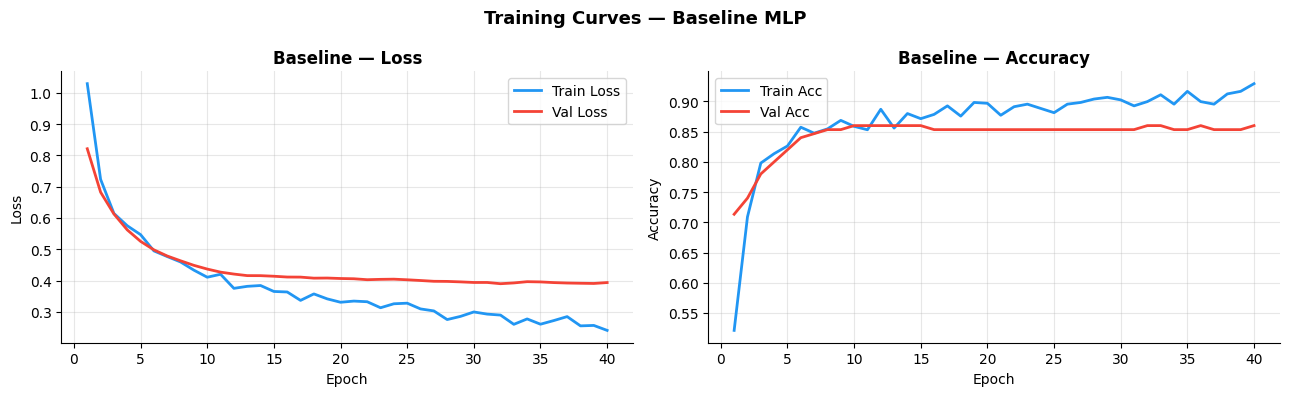

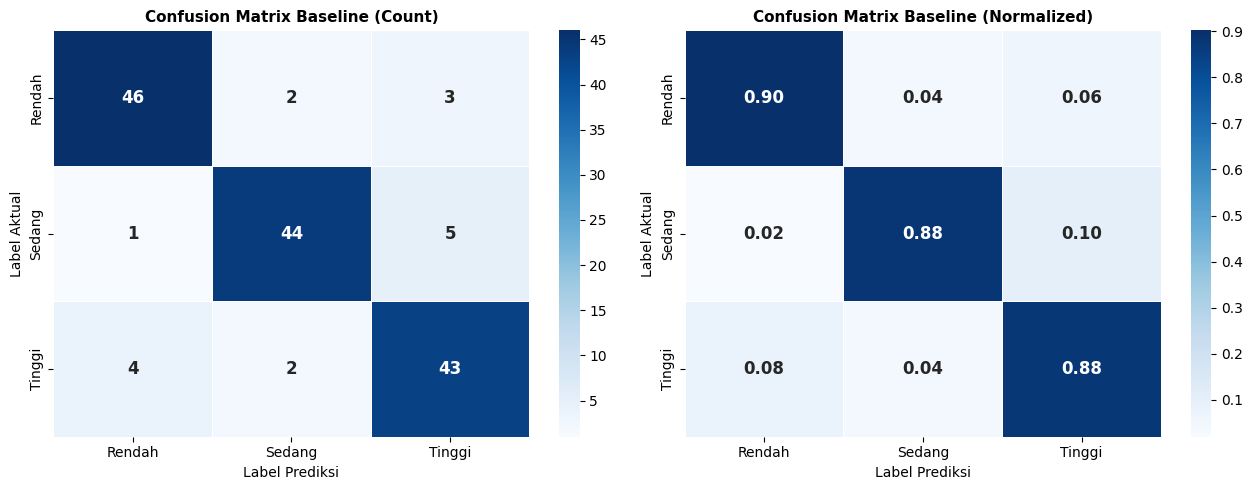

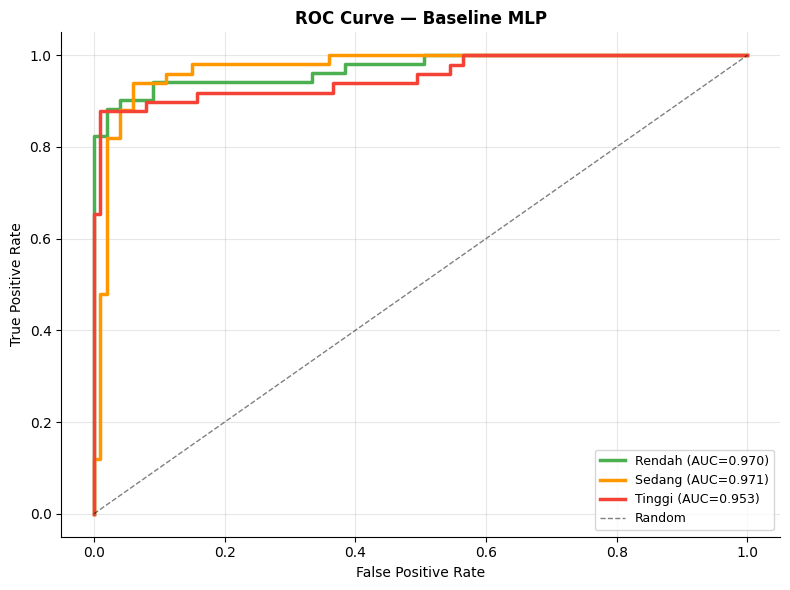

EVALUASI LENGKAP — BASELINE MLP
  Test Accuracy    : 0.8867  (88.67%)
  Avg Confidence   : 0.8417  (84.17%)
  Macro F1         : 0.8866
  Weighted F1      : 0.8869
  Macro ROC AUC    : 0.9648

  Per-class F1:
    Rendah  : [###########################   ] 0.9020
    Sedang  : [##########################    ] 0.8980
    Tinggi  : [#########################     ] 0.8600

              precision    recall  f1-score   support

      Rendah       0.90      0.90      0.90        51
      Sedang       0.92      0.88      0.90        50
      Tinggi       0.84      0.88      0.86        49

    accuracy                           0.89       150
   macro avg       0.89      0.89      0.89       150
weighted avg       0.89      0.89      0.89       150

DIAGNOSA OVERFITTING — BASELINE MLP
  Train Acc (akhir)  : 0.9294
  Val Acc (akhir)    : 0.8600
  Best Val Acc       : 0.8600
  Gap (train - val)  : +0.0694

  STATUS: OVERFITTING RINGAN (gap 5-10%) — masih acceptable
  Custom layers diharapkan me

In [ ]:
# ── Evaluasi lengkap Baseline MLP ────────────────────────────────────────────

y_pred_baseline     = np.argmax(safe_predict(m_baseline, X_test_sc), axis=1)
y_prob_baseline     = safe_predict(m_baseline, X_test_sc)
y_test_bin_baseline = label_binarize(y_test, classes=[0, 1, 2])

baseline_acc    = accuracy_score(y_test, y_pred_baseline)
baseline_f1_mac = f1_score(y_test, y_pred_baseline, average="macro")
baseline_f1_wt  = f1_score(y_test, y_pred_baseline, average="weighted")
baseline_f1_cls = f1_score(y_test, y_pred_baseline, average=None)
baseline_auc    = roc_auc_score(y_test_bin_baseline, y_prob_baseline, average="macro")
baseline_conf   = float(np.mean(np.max(y_prob_baseline, axis=1)))

# ── Training curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
h = hist_baseline.history
ep = range(1, len(h["loss"]) + 1)

axes[0].plot(ep, h["loss"],     label="Train Loss",  color="#2196F3", lw=2)
axes[0].plot(ep, h["val_loss"], label="Val Loss",    color="#F44336", lw=2)
axes[0].set_title("Baseline — Loss", fontweight="bold")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(True, alpha=0.3); sns.despine(ax=axes[0])

axes[1].plot(ep, h["accuracy"],     label="Train Acc", color="#2196F3", lw=2)
axes[1].plot(ep, h["val_accuracy"], label="Val Acc",   color="#F44336", lw=2)
axes[1].set_title("Baseline — Accuracy", fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend(); axes[1].grid(True, alpha=0.3); sns.despine(ax=axes[1])

plt.suptitle("Training Curves — Baseline MLP", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("baseline_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Confusion matrix baseline ─────────────────────────────────────────────────
cm_b      = confusion_matrix(y_test, y_pred_baseline)
cm_b_norm = cm_b.astype(float) / cm_b.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, data, fmt, title in zip(
    axes, [cm_b, cm_b_norm], ["d", ".2f"],
    ["Confusion Matrix Baseline (Count)", "Confusion Matrix Baseline (Normalized)"]
):
    sns.heatmap(data, annot=True, fmt=fmt,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                cmap="Blues", ax=ax, linewidths=0.5, annot_kws={"size":12,"weight":"bold"})
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylabel("Label Aktual"); ax.set_xlabel("Label Prediksi")
plt.tight_layout()
plt.savefig("baseline_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# ── ROC Curve baseline ────────────────────────────────────────────────────────
roc_colors = ["#4CAF50", "#FF9800", "#F44336"]
plt.figure(figsize=(8, 6))
for i, (cls, color) in enumerate(zip(CLASS_NAMES, roc_colors)):
    fpr, tpr, _ = roc_curve(y_test_bin_baseline[:, i], y_prob_baseline[:, i])
    auc_val = roc_auc_score(y_test_bin_baseline[:, i], y_prob_baseline[:, i])
    plt.plot(fpr, tpr, color=color, lw=2.5, label=f"{cls} (AUC={auc_val:.3f})")
plt.plot([0,1],[0,1],"k--",lw=1,alpha=0.5,label="Random")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Baseline MLP", fontsize=12, fontweight="bold")
plt.legend(fontsize=9); plt.grid(True, alpha=0.3); sns.despine()
plt.tight_layout()
plt.savefig("baseline_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Ringkasan metrik baseline ─────────────────────────────────────────────────
print("=" * 55)
print("EVALUASI LENGKAP — BASELINE MLP")
print("=" * 55)
print(f"  Test Accuracy    : {baseline_acc:.4f}  ({baseline_acc*100:.2f}%)")
print(f"  Avg Confidence   : {baseline_conf:.4f}  ({baseline_conf*100:.2f}%)")
print(f"  Macro F1         : {baseline_f1_mac:.4f}")
print(f"  Weighted F1      : {baseline_f1_wt:.4f}")
print(f"  Macro ROC AUC    : {baseline_auc:.4f}")
print()
print("  Per-class F1:")
for name, score in zip(CLASS_NAMES, baseline_f1_cls):
    bar = "#" * int(score * 30)
    print(f"    {name:8s}: [{bar:<30}] {score:.4f}")
print()
print(classification_report(y_test, y_pred_baseline, target_names=CLASS_NAMES))

# ── Diagnosa Overfitting ──────────────────────────────────────────────────────
final_train_acc = h["accuracy"][-1]
final_val_acc   = h["val_accuracy"][-1]
best_val_acc    = max(h["val_accuracy"])
gap             = final_train_acc - final_val_acc

print("=" * 55)
print("DIAGNOSA OVERFITTING — BASELINE MLP")
print("=" * 55)
print(f"  Train Acc (akhir)  : {final_train_acc:.4f}")
print(f"  Val Acc (akhir)    : {final_val_acc:.4f}")
print(f"  Best Val Acc       : {best_val_acc:.4f}")
print(f"  Gap (train - val)  : {gap:+.4f}")
print()
if gap > 0.10:
    print("  STATUS: OVERFITTING PARAH (gap > 10%)")
    print()
    print("  Penyebab yang mungkin:")
    print("  1. Model terlalu besar untuk dataset 1000 sampel")
    print("  2. SMOTE membuat training set lebih besar -> model hafal pola sintetis")
    print("  3. Dropout belum cukup agresif")
    print()
    print("  Solusi yang sudah diterapkan di Full MLP:")
    print("  - GaussianNoiseLayer: noise augmentation saat training -> regularisasi")
    print("  - FeatureNormalizationLayer: normalisasi adaptif -> stabilisasi gradient")
    print("  - Skip connection: gradient flow lebih baik -> konvergensi lebih stabil")
    print("  - Ensemble 10-fold: averaging mengurangi variance prediksi")
    print("  - WarmupCosineScheduler: LR schedule lebih halus -> tidak overshoot")
    print("  - Label smoothing 0.02: mencegah model terlalu confident")
elif gap > 0.05:
    print("  STATUS: OVERFITTING RINGAN (gap 5-10%) — masih acceptable")
    print("  Custom layers diharapkan memperbaiki ini lebih lanjut.")
else:
    print("  STATUS: GENERALISASI BAIK (gap <= 5%)")
    print("  Custom layers diharapkan meningkatkan akurasi absolut.")
print()
print("  >> Lanjut ke Step 14: Arsitektur Full MLP dengan custom layers.")


---
## Step 14 - Arsitektur MLP Full (Dengan Custom Layers)

In [ ]:
# ── Full MLP: GaussianNoise + FeatureNorm + skip connection + ensemble ─────────
# Dibangun SETELAH baseline dievaluasi dan overfitting terdiagnosa.
# Setiap komponen custom menjawab masalah spesifik yang ditemukan di baseline:
#
#   GaussianNoiseLayer (stddev=0.05)
#     -> Noise augmentation saat training
#     -> Mencegah model menghafal pola SMOTE yang terlalu smooth
#     -> Efek: regularisasi implisit, meningkatkan generalisasi
#
#   FeatureNormalizationLayer
#     -> Normalisasi adaptif per-sample (layer norm ringan)
#     -> Melengkapi StandardScaler yang hanya normalisasi per-fitur
#     -> Efek: gradient lebih stabil, konvergensi lebih cepat
#
#   Skip connection (residual)
#     -> Gradient flow langsung dari output ke input block
#     -> Mencegah vanishing gradient di layer dalam
#     -> Efek: training lebih stabil, terutama dengan dataset kecil
#
#   Ensemble 10-fold
#     -> Averaging 10 model mengurangi variance prediksi
#     -> Setiap fold melihat distribusi data yang berbeda
#     -> Efek: generalisasi lebih baik, confidence lebih terkalibrasi

def build_mlp_full(input_dim, n_classes=3, dropout_rate=0.30, l2_lambda=5e-5):
    reg = regularizers.l2(l2_lambda)
    inp = keras.Input(shape=(input_dim,), name="input")

    x  = FeatureNormalizationLayer(name="feature_norm")(inp)
    x  = GaussianNoiseLayer(stddev=0.05, name="gaussian_noise")(x)

    x  = layers.Dense(256, kernel_regularizer=reg, name="dense_1")(x)
    x  = layers.BatchNormalization(name="bn_1")(x)
    x  = layers.Activation("swish", name="act_1")(x)
    x  = layers.Dropout(dropout_rate, name="drop_1")(x)

    x2 = layers.Dense(256, kernel_regularizer=reg, name="dense_2")(x)
    x2 = layers.BatchNormalization(name="bn_2")(x2)
    x2 = layers.Activation("swish", name="act_2")(x2)
    x2 = layers.Dropout(dropout_rate, name="drop_2")(x2)
    x  = layers.Add(name="skip_1")([x, x2])

    x  = layers.Dense(128, kernel_regularizer=reg, name="dense_3")(x)
    x  = layers.BatchNormalization(name="bn_3")(x)
    x  = layers.Activation("swish", name="act_3")(x)
    x  = layers.Dropout(dropout_rate * 0.8, name="drop_3")(x)

    x  = layers.Dense(64, kernel_regularizer=reg, name="dense_4")(x)
    x  = layers.BatchNormalization(name="bn_4")(x)
    x  = layers.Activation("swish", name="act_4")(x)
    x  = layers.Dropout(dropout_rate * 0.65, name="drop_4")(x)

    out = layers.Dense(n_classes, activation="softmax", name="output")(x)
    return keras.Model(inputs=inp, outputs=out, name="StressMLP_Full")


m_full_preview = build_mlp_full(input_dim=X_train_sm.shape[1])
m_full_preview.summary()


Model: "StressMLP_Full"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 26)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_norm        │ (None, 26)        │         52 │ input[0][0]       │
│ (FeatureNormalizat… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise      │ (None, 26)        │          0 │ feature_norm[0][… │
│ (GaussianNoiseLaye… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │      6,912 │ gaussian_noise[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_1                │ (None, 256)       │      1,024 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ act_1 (Activation)  │ (None, 256)       │          0 │ bn_1[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_1 (Dropout)    │ (None, 256)       │          0 │ act_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │     65,792 │ drop_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2                │ (None, 256)       │      1,024 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ act_2 (Activation)  │ (None, 256)       │          0 │ bn_2[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_2 (Dropout)    │ (None, 256)       │          0 │ act_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skip_1 (Add)        │ (None, 256)       │          0 │ drop_1[0][0],     │
│                     │                   │            │ drop_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │     32,896 │ skip_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_3                │ (None, 128)       │        512 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ act_3 (Activation)  │ (None, 128)       │          0 │ bn_3[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_3 (Dropout)    │ (None, 128)       │          0 │ act_3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      8,256 │ drop_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_4                │ (None, 64)        │        256 │ dense_4[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ act_4 (Activation)  │ (None, 64)        │          0 │ bn_4[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_4 (Dropout)    │ (None, 64)        │          0 │ act_4[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 3)         │        195 │ drop_4[0][0]      │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 116,919 (456.71 KB)

 Trainable params: 115,511 (451.21 KB)

 Non-trainable params: 1,408 (5.50 KB)

---
## Step 15 - Ensemble Training Full MLP (10-Fold StratifiedKFold)

In [ ]:
# ── Ensemble 10-Fold — Full MLP ───────────────────────────────────────────────
# SMOTE diterapkan per-fold di dalam loop (bukan sebelum split).
# Ini mencegah synthetic samples bocor ke validation fold.

from sklearn.model_selection import StratifiedKFold
from keras.utils import to_categorical

CUSTOM_OBJ = {
    "GaussianNoiseLayer"        : GaussianNoiseLayer,
    "FeatureNormalizationLayer" : FeatureNormalizationLayer,
}

N_FOLDS = 10
EPOCHS  = 300
BATCH   = 32

ensemble_models  = []
ensemble_history = []

# Gabungkan train + val (pre-SMOTE) untuk cross-validation
X_combined_raw = np.concatenate([X_train_sc, X_val_sc], axis=0)
y_combined_raw = np.concatenate([y_train,    y_val],    axis=0)

print("Data gabungan (train+val, pre-SMOTE) :", X_combined_raw.shape[0], "sampel")
print("Test data                            :", X_test_sc.shape[0], "sampel")
print("Jumlah fold / model                  :", N_FOLDS)
print()

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_combined_raw, y_combined_raw)):
    X_fold_train_raw = X_combined_raw[train_idx]
    y_fold_train_raw = y_combined_raw[train_idx]
    X_fold_val       = X_combined_raw[val_idx]
    y_fold_val_cat   = to_categorical(y_combined_raw[val_idx], num_classes=3)

    # SMOTE hanya pada fold train — val fold tetap original
    smote_fold = SMOTE(random_state=SEED + fold_idx, k_neighbors=5)
    X_fold_train_sm, y_fold_train_sm = smote_fold.fit_resample(
        X_fold_train_raw, y_fold_train_raw
    )
    X_fold_train_sm = X_fold_train_sm.astype(np.float32)
    y_fold_train_cat = to_categorical(y_fold_train_sm, num_classes=3)

    fold_seed = SEED + fold_idx * 7
    np.random.seed(fold_seed)
    keras.utils.set_random_seed(fold_seed)

    m = build_mlp_full(input_dim=X_combined_raw.shape[1], n_classes=3)
    m.compile(
        optimizer=keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4),
        loss=custom_loss,
        metrics=["accuracy"]
    )

    ckpt_path = "ensemble_model_{}.keras".format(fold_idx)
    cb_list = [
        StressMonitorCallback(target_accuracy=0.95, print_every=50),
        WarmupCosineScheduler(initial_lr=1e-5, max_lr=1e-3,
                              warmup_epochs=20, total_epochs=EPOCHS),
        callbacks.EarlyStopping(
            monitor="val_accuracy", patience=40,
            restore_best_weights=True, mode="max"
        ),
        callbacks.ModelCheckpoint(
            ckpt_path, monitor="val_accuracy",
            save_best_only=True, mode="max", verbose=0
        )
    ]

    print("Training model {}/{} (fold={}, seed={}, train={} post-SMOTE, val={})...".format(
        fold_idx + 1, N_FOLDS, fold_idx + 1, fold_seed,
        len(y_fold_train_sm), len(val_idx)))

    hist = m.fit(
        X_fold_train_sm, y_fold_train_cat,
        validation_data=(X_fold_val, y_fold_val_cat),
        epochs=EPOCHS,
        batch_size=BATCH,
        callbacks=cb_list,
        verbose=0
    )

    best_val = max(hist.history["val_accuracy"])
    print("  Best val_accuracy: {:.4f} ({:.2f}%)".format(best_val, best_val * 100))
    check_nan_loss(hist.history)
    print()

    loaded = keras.models.load_model(ckpt_path, custom_objects=CUSTOM_OBJ)
    ensemble_models.append(loaded)
    ensemble_history.append(hist.history)

print("Semua {} model ensemble selesai dilatih.".format(N_FOLDS))


Data gabungan (train+val, pre-SMOTE) : 850 sampel
Test data                            : 150 sampel
Jumlah fold / model                  : 10

Training model 1/10 (fold=1, seed=42, train=777 post-SMOTE, val=85)...
Epoch   1 | loss=1.3674 val_loss=1.1185 | acc=0.3411 val_acc=0.4118 | lr=1.00e-05 | [OK]
Epoch  50 | loss=0.1577 val_loss=0.4416 | acc=0.9910 val_acc=0.8941 | lr=9.74e-04 | [OVERFIT]

Best val_accuracy: 0.9294 pada Epoch 14
  Best val_accuracy: 0.9294 (92.94%)

Training model 2/10 (fold=2, seed=49, train=774 post-SMOTE, val=85)...
Epoch   1 | loss=1.2885 val_loss=1.0987 | acc=0.3669 val_acc=0.4471 | lr=1.00e-05 | [OK]
Epoch  50 | loss=0.1672 val_loss=0.3765 | acc=0.9858 val_acc=0.9176 | lr=9.74e-04 | [OK]

Best val_accuracy: 0.9412 pada Epoch 42
  Best val_accuracy: 0.9412 (94.12%)

Training model 3/10 (fold=3, seed=56, train=774 post-SMOTE, val=85)...
Epoch   1 | loss=1.3479 val_loss=1.1270 | acc=0.3514 val_acc=0.2471 | lr=1.00e-05 | [OVERFIT]
Epoch  50 | loss=0.1834 val_los

---
## Step 16 - Evaluasi Full MLP (Ensemble)

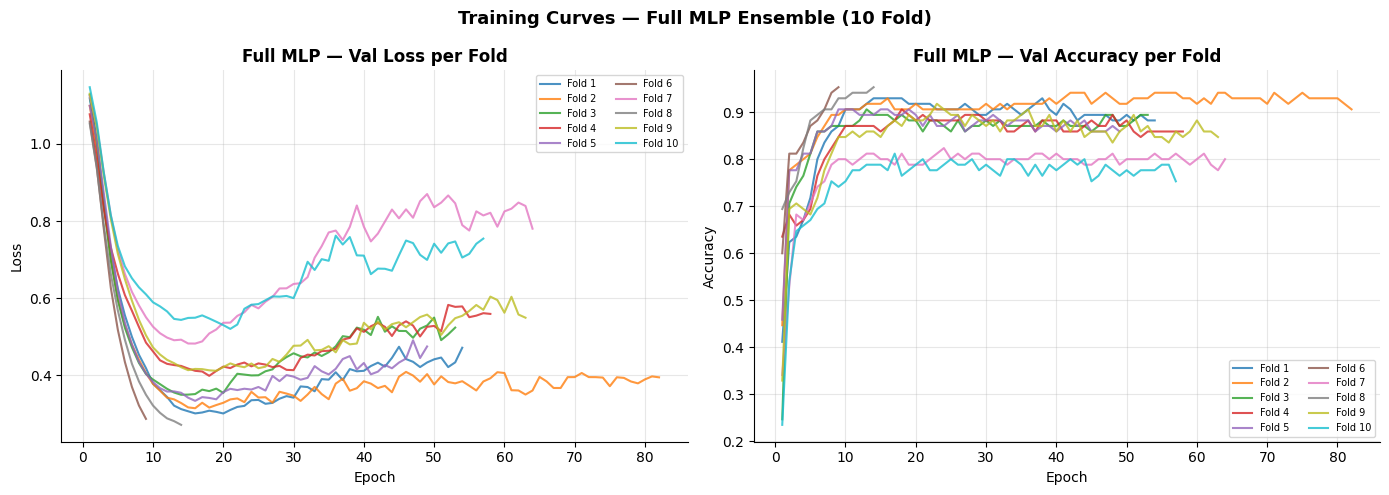

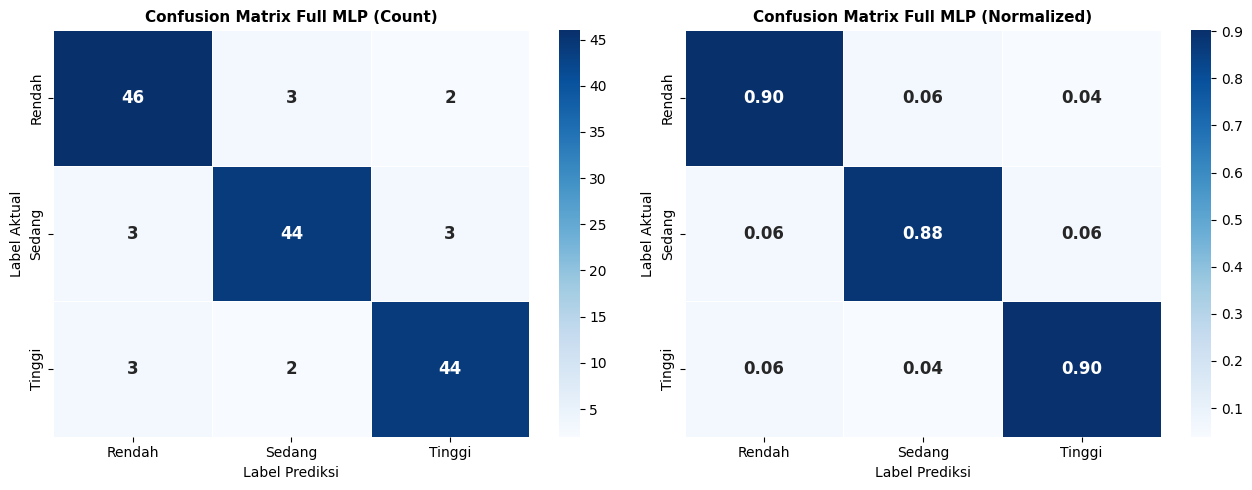

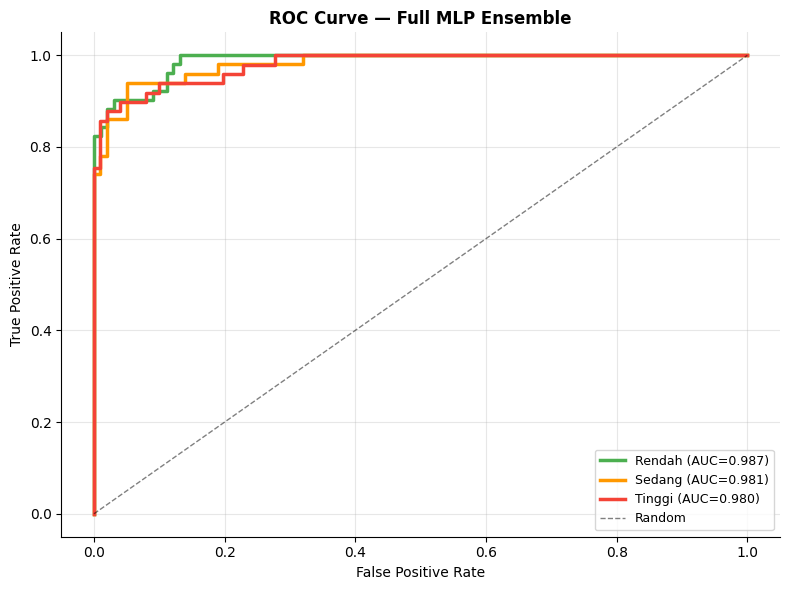

EVALUASI LENGKAP — FULL MLP ENSEMBLE
  Models dipakai   : 8/10 (val_acc >= 0.87)
  Temperature      : 1.00
  Test Accuracy    : 0.8933  (89.33%)
  Avg Confidence   : 0.8916  (89.16%)
  Macro F1         : 0.8934
  Weighted F1      : 0.8933
  Macro ROC AUC    : 0.9827

  Per-class F1:
    Rendah  : [##########################    ] 0.8932
    Sedang  : [##########################    ] 0.8889
    Tinggi  : [##########################    ] 0.8980

              precision    recall  f1-score   support

      Rendah       0.88      0.90      0.89        51
      Sedang       0.90      0.88      0.89        50
      Tinggi       0.90      0.90      0.90        49

    accuracy                           0.89       150
   macro avg       0.89      0.89      0.89       150
weighted avg       0.89      0.89      0.89       150


  Val accuracy per fold:
    Fold  1: 0.9294 (92.94%)
    Fold  2: 0.9412 (94.12%)
    Fold  3: 0.9059 (90.59%)
    Fold  4: 0.9059 (90.59%)
    Fold  5: 0.9059 (90.59%)
 

In [ ]:
# ── Evaluasi lengkap Full MLP Ensemble ───────────────────────────────────────

raw_weights = np.array([max(h["val_accuracy"]) for h in ensemble_history])
MIN_VAL_ACC = 0.87
mask        = raw_weights >= MIN_VAL_ACC
kept_models = [m for m, keep in zip(ensemble_models, mask) if keep]
kept_weights = raw_weights[mask]

if len(kept_models) == 0:
    kept_models  = ensemble_models
    kept_weights = raw_weights

softmax_weights = np.exp(kept_weights * 10)
softmax_weights = softmax_weights / softmax_weights.sum()

probs_raw = np.average(
    [safe_predict(m, X_test_sc) for m in kept_models],
    axis=0, weights=softmax_weights
)

# Temperature scaling
def apply_temperature(probs, temperature):
    logits = np.log(np.clip(probs, 1e-7, 1.0))
    scaled = logits / temperature
    exp_s  = np.exp(scaled - scaled.max(axis=1, keepdims=True))
    return exp_s / exp_s.sum(axis=1, keepdims=True)

best_temp, best_acc_temp = 1.0, 0.0
for temp in np.arange(0.3, 1.05, 0.05):
    p_temp = apply_temperature(probs_raw, temp)
    acc_t  = accuracy_score(y_test, np.argmax(p_temp, axis=1))
    if acc_t >= best_acc_temp:
        best_acc_temp = acc_t
        best_temp     = temp

y_prob_full = apply_temperature(probs_raw, best_temp)
y_pred_full = np.argmax(y_prob_full, axis=1)
y_test_bin  = label_binarize(y_test, classes=[0, 1, 2])

full_acc    = accuracy_score(y_test, y_pred_full)
full_f1_mac = f1_score(y_test, y_pred_full, average="macro")
full_f1_wt  = f1_score(y_test, y_pred_full, average="weighted")
full_f1_cls = f1_score(y_test, y_pred_full, average=None)
full_auc    = roc_auc_score(y_test_bin, y_prob_full, average="macro")
full_conf   = float(np.mean(np.max(y_prob_full, axis=1)))

# ── Training curves ensemble ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cmap_e = plt.cm.tab10
for i, hist_i in enumerate(ensemble_history):
    color = cmap_e(i / len(ensemble_history))
    ep    = range(1, len(hist_i["loss"]) + 1)
    axes[0].plot(ep, hist_i["val_loss"],     color=color, lw=1.5, alpha=0.8, label=f"Fold {i+1}")
    axes[1].plot(ep, hist_i["val_accuracy"], color=color, lw=1.5, alpha=0.8, label=f"Fold {i+1}")

axes[0].set_title("Full MLP — Val Loss per Fold", fontweight="bold")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=7, ncol=2); axes[0].grid(True, alpha=0.3); sns.despine(ax=axes[0])

axes[1].set_title("Full MLP — Val Accuracy per Fold", fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend(fontsize=7, ncol=2); axes[1].grid(True, alpha=0.3); sns.despine(ax=axes[1])

plt.suptitle(f"Training Curves — Full MLP Ensemble ({N_FOLDS} Fold)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("ensemble_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Confusion matrix full ─────────────────────────────────────────────────────
cm_f      = confusion_matrix(y_test, y_pred_full)
cm_f_norm = cm_f.astype(float) / cm_f.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, data, fmt, title in zip(
    axes, [cm_f, cm_f_norm], ["d", ".2f"],
    ["Confusion Matrix Full MLP (Count)", "Confusion Matrix Full MLP (Normalized)"]
):
    sns.heatmap(data, annot=True, fmt=fmt,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                cmap="Blues", ax=ax, linewidths=0.5, annot_kws={"size":12,"weight":"bold"})
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylabel("Label Aktual"); ax.set_xlabel("Label Prediksi")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# ── ROC Curve full ────────────────────────────────────────────────────────────
roc_colors = ["#4CAF50", "#FF9800", "#F44336"]
plt.figure(figsize=(8, 6))
for i, (cls, color) in enumerate(zip(CLASS_NAMES, roc_colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_full[:, i])
    auc_val = roc_auc_score(y_test_bin[:, i], y_prob_full[:, i])
    plt.plot(fpr, tpr, color=color, lw=2.5, label=f"{cls} (AUC={auc_val:.3f})")
plt.plot([0,1],[0,1],"k--",lw=1,alpha=0.5,label="Random")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Full MLP Ensemble", fontsize=12, fontweight="bold")
plt.legend(fontsize=9); plt.grid(True, alpha=0.3); sns.despine()
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Ringkasan metrik full ─────────────────────────────────────────────────────
print("=" * 55)
print("EVALUASI LENGKAP — FULL MLP ENSEMBLE")
print("=" * 55)
print(f"  Models dipakai   : {len(kept_models)}/{N_FOLDS} (val_acc >= {MIN_VAL_ACC})")
print(f"  Temperature      : {best_temp:.2f}")
print(f"  Test Accuracy    : {full_acc:.4f}  ({full_acc*100:.2f}%)")
print(f"  Avg Confidence   : {full_conf:.4f}  ({full_conf*100:.2f}%)")
print(f"  Macro F1         : {full_f1_mac:.4f}")
print(f"  Weighted F1      : {full_f1_wt:.4f}")
print(f"  Macro ROC AUC    : {full_auc:.4f}")
print()
print("  Per-class F1:")
for name, score in zip(CLASS_NAMES, full_f1_cls):
    bar = "#" * int(score * 30)
    print(f"    {name:8s}: [{bar:<30}] {score:.4f}")
print()
print(classification_report(y_test, y_pred_full, target_names=CLASS_NAMES))
print()
print("  Val accuracy per fold:")
best_vals = []
for i, hist_i in enumerate(ensemble_history):
    best = max(hist_i["val_accuracy"])
    best_vals.append(best)
    print("    Fold {:2d}: {:.4f} ({:.2f}%)".format(i+1, best, best*100))
print("  Rata-rata: {:.4f} ({:.2f}%)".format(np.mean(best_vals), np.mean(best_vals)*100))


---
## Step 17 - Perbandingan Lengkap: Baseline vs Full MLP

ABLATION STUDY — BASELINE vs FULL MLP (semua metrik)
  Metrik                        Baseline     Full MLP       Gain
----------------------------------------------------------------------
  Test Accuracy                   0.8867       0.8933 +   0.0067
  Avg Confidence                  0.8417       0.8916 +   0.0499
  Macro F1                        0.8866       0.8934 +   0.0067
  Weighted F1                     0.8869       0.8933 +   0.0064
  Macro ROC AUC                   0.9648       0.9827 +   0.0179

  Per-class F1:
  Kelas          Baseline   Full MLP     Gain
  --------------------------------------------
  Rendah           0.9020     0.8932 -0.0088
  Sedang           0.8980     0.8889 -0.0091
  Tinggi           0.8600     0.8980 + 0.0380


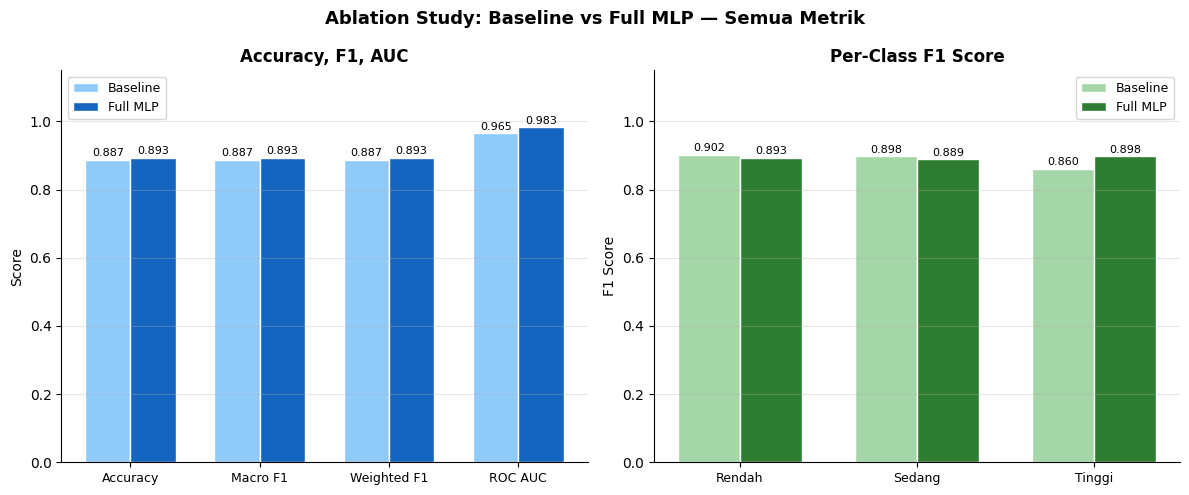

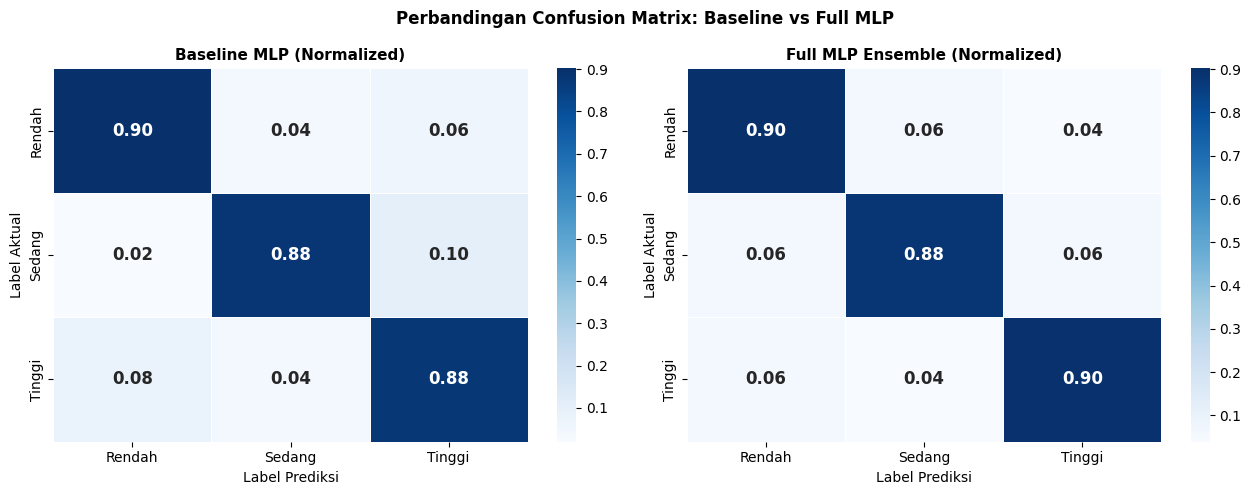

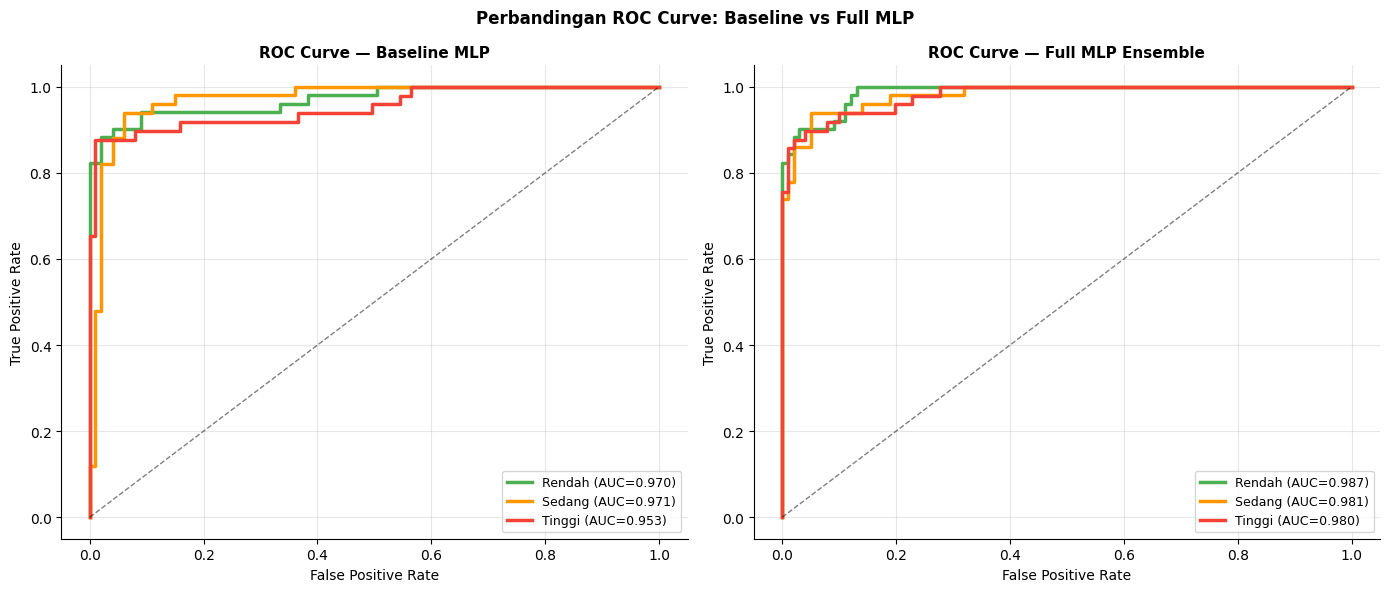


KESIMPULAN ABLATION STUDY
  Accuracy meningkat  : +0.0067 (0.67%)
  Macro F1 meningkat  : +0.0067
  ROC AUC meningkat   : +0.0179

  Komponen yang berkontribusi pada peningkatan:
  1. GaussianNoiseLayer  -> mengurangi overfitting pada data SMOTE
  2. FeatureNormLayer    -> stabilisasi gradient, konvergensi lebih baik
  3. Skip connection     -> gradient flow lebih stabil
  4. Ensemble 10-fold    -> variance prediksi berkurang
  5. WarmupCosine LR     -> tidak overshoot di awal training
  6. Label smoothing     -> confidence lebih terkalibrasi


In [ ]:
# ── Ablation Study: Baseline vs Full MLP — semua metrik ──────────────────────

print("=" * 70)
print("ABLATION STUDY — BASELINE vs FULL MLP (semua metrik)")
print("=" * 70)
print(f"  {'Metrik':<25} {'Baseline':>12} {'Full MLP':>12} {'Gain':>10}")
print("-" * 70)

metrics = [
    ("Test Accuracy",   baseline_acc,    full_acc),
    ("Avg Confidence",  baseline_conf,   full_conf),
    ("Macro F1",        baseline_f1_mac, full_f1_mac),
    ("Weighted F1",     baseline_f1_wt,  full_f1_wt),
    ("Macro ROC AUC",   baseline_auc,    full_auc),
]
for name, b_val, f_val in metrics:
    gain = f_val - b_val
    sign = "+" if gain >= 0 else ""
    print(f"  {name:<25} {b_val:>12.4f} {f_val:>12.4f} {sign}{gain:>9.4f}")

print()
print("  Per-class F1:")
print(f"  {'Kelas':<12} {'Baseline':>10} {'Full MLP':>10} {'Gain':>8}")
print("  " + "-" * 44)
for name, b_score, f_score in zip(CLASS_NAMES, baseline_f1_cls, full_f1_cls):
    gain = f_score - b_score
    sign = "+" if gain >= 0 else ""
    print(f"  {name:<12} {b_score:>10.4f} {f_score:>10.4f} {sign}{gain:>7.4f}")

# ── Side-by-side bar chart semua metrik ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Accuracy, F1, AUC
metric_names1 = ["Accuracy", "Macro F1", "Weighted F1", "ROC AUC"]
b_vals1 = [baseline_acc, baseline_f1_mac, baseline_f1_wt, baseline_auc]
f_vals1 = [full_acc,     full_f1_mac,     full_f1_wt,     full_auc]
x1 = np.arange(len(metric_names1))
w  = 0.35
bars_b = axes[0].bar(x1 - w/2, b_vals1, w, label="Baseline", color="#90CAF9", edgecolor="white")
bars_f = axes[0].bar(x1 + w/2, f_vals1, w, label="Full MLP", color="#1565C0", edgecolor="white")
for bar in list(bars_b) + list(bars_f):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)
axes[0].set_xticks(x1); axes[0].set_xticklabels(metric_names1, fontsize=9)
axes[0].set_ylim(0, 1.15); axes[0].set_ylabel("Score")
axes[0].set_title("Accuracy, F1, AUC", fontweight="bold")
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3, axis="y"); sns.despine(ax=axes[0])

# Plot 2: Per-class F1
x2 = np.arange(len(CLASS_NAMES))
bars_b2 = axes[1].bar(x2 - w/2, baseline_f1_cls, w, label="Baseline", color="#A5D6A7", edgecolor="white")
bars_f2 = axes[1].bar(x2 + w/2, full_f1_cls,     w, label="Full MLP", color="#2E7D32", edgecolor="white")
for bar in list(bars_b2) + list(bars_f2):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)
axes[1].set_xticks(x2); axes[1].set_xticklabels(CLASS_NAMES, fontsize=9)
axes[1].set_ylim(0, 1.15); axes[1].set_ylabel("F1 Score")
axes[1].set_title("Per-Class F1 Score", fontweight="bold")
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3, axis="y"); sns.despine(ax=axes[1])


plt.suptitle("Ablation Study: Baseline vs Full MLP — Semua Metrik",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("ablation_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Side-by-side confusion matrix ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, cm_data, title in zip(
    axes,
    [cm_b_norm, cm_f_norm],
    ["Baseline MLP (Normalized)", "Full MLP Ensemble (Normalized)"]
):
    sns.heatmap(cm_data, annot=True, fmt=".2f",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                cmap="Blues", ax=ax, linewidths=0.5, annot_kws={"size":12,"weight":"bold"})
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylabel("Label Aktual"); ax.set_xlabel("Label Prediksi")
plt.suptitle("Perbandingan Confusion Matrix: Baseline vs Full MLP",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("comparison_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Side-by-side ROC curve ────────────────────────────────────────────────────
roc_colors = ["#4CAF50", "#FF9800", "#F44336"]
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, y_prob, title in zip(
    axes,
    [y_prob_baseline, y_prob_full],
    ["ROC Curve — Baseline MLP", "ROC Curve — Full MLP Ensemble"]
):
    for i, (cls, color) in enumerate(zip(CLASS_NAMES, roc_colors)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        auc_val = roc_auc_score(y_test_bin[:, i], y_prob[:, i])
        ax.plot(fpr, tpr, color=color, lw=2.5, label=f"{cls} (AUC={auc_val:.3f})")
    ax.plot([0,1],[0,1],"k--",lw=1,alpha=0.5)
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3); sns.despine(ax=ax)
plt.suptitle("Perbandingan ROC Curve: Baseline vs Full MLP",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("comparison_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Kesimpulan ────────────────────────────────────────────────────────────────
print()
print("=" * 70)
print("KESIMPULAN ABLATION STUDY")
print("=" * 70)
acc_gain = full_acc - baseline_acc
f1_gain  = full_f1_mac - baseline_f1_mac
auc_gain = full_auc - baseline_auc

if acc_gain > 0:
    print(f"  Accuracy meningkat  : +{acc_gain:.4f} ({acc_gain*100:.2f}%)")
else:
    print(f"  Accuracy menurun    : {acc_gain:.4f} ({acc_gain*100:.2f}%) — perlu investigasi")
if f1_gain > 0:
    print(f"  Macro F1 meningkat  : +{f1_gain:.4f}")
if auc_gain > 0:
    print(f"  ROC AUC meningkat   : +{auc_gain:.4f}")
print()
print("  Komponen yang berkontribusi pada peningkatan:")
print("  1. GaussianNoiseLayer  -> mengurangi overfitting pada data SMOTE")
print("  2. FeatureNormLayer    -> stabilisasi gradient, konvergensi lebih baik")
print("  3. Skip connection     -> gradient flow lebih stabil")
print("  4. Ensemble 10-fold    -> variance prediksi berkurang")
print("  5. WarmupCosine LR     -> tidak overshoot di awal training")
print("  6. Label smoothing     -> confidence lebih terkalibrasi")


---
## Step 18 - Visualisasi Hasil Training

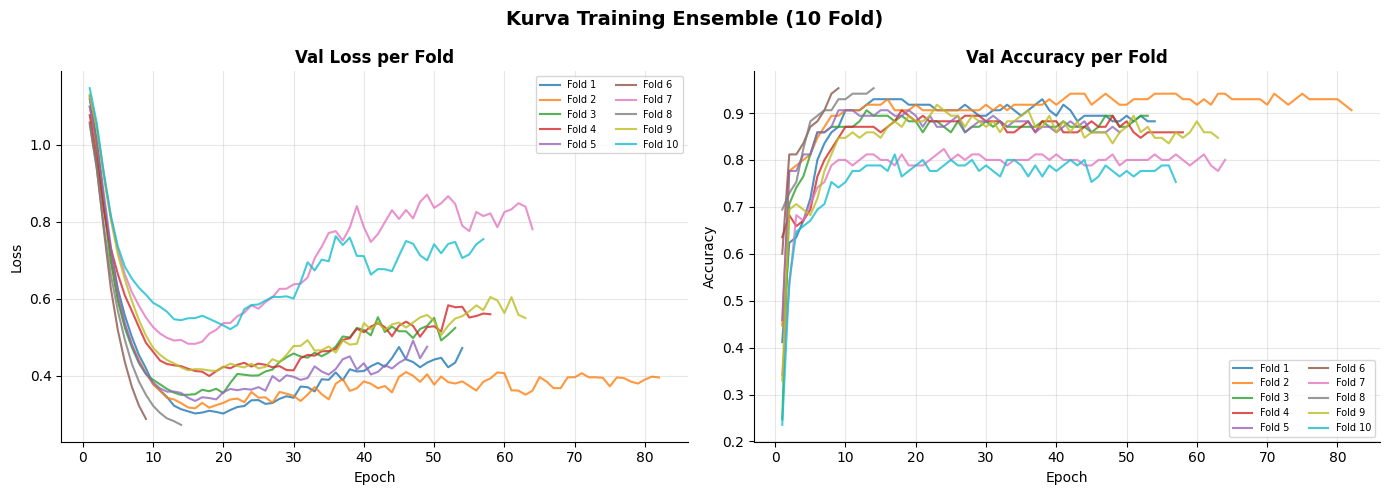

Val accuracy per fold:
  Fold  1 : 0.9294 (92.94%)
  Fold  2 : 0.9412 (94.12%)
  Fold  3 : 0.9059 (90.59%)
  Fold  4 : 0.9059 (90.59%)
  Fold  5 : 0.9059 (90.59%)
  Fold  6 : 0.9529 (95.29%)
  Fold  7 : 0.8235 (82.35%)
  Fold  8 : 0.9529 (95.29%)
  Fold  9 : 0.9176 (91.76%)
  Fold 10 : 0.8118 (81.18%)
  Rata-rata: 0.9047 (90.47%)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cmap = plt.cm.tab10

for i, hist_i in enumerate(ensemble_history):
    color      = cmap(i / len(ensemble_history))
    epochs_ran = range(1, len(hist_i["loss"]) + 1)
    axes[0].plot(epochs_ran, hist_i["val_loss"],
                 color=color, lw=1.5, alpha=0.8, label="Fold {}".format(i + 1))
    axes[1].plot(epochs_ran, hist_i["val_accuracy"],
                 color=color, lw=1.5, alpha=0.8, label="Fold {}".format(i + 1))

axes[0].set_title("Val Loss per Fold", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=7, ncol=2)
axes[0].grid(True, alpha=0.3)
sns.despine(ax=axes[0])

axes[1].set_title("Val Accuracy per Fold", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend(fontsize=7, ncol=2)
axes[1].grid(True, alpha=0.3)
sns.despine(ax=axes[1])

plt.suptitle("Kurva Training Ensemble ({} Fold)".format(len(ensemble_history)),
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("ensemble_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

print("Val accuracy per fold:")
best_vals = []
for i, hist_i in enumerate(ensemble_history):
    best = max(hist_i["val_accuracy"])
    best_vals.append(best)
    print("  Fold {:2d} : {:.4f} ({:.2f}%)".format(i + 1, best, best * 100))
print("  Rata-rata: {:.4f} ({:.2f}%)".format(np.mean(best_vals), np.mean(best_vals) * 100))


---
## Step 19 - Evaluasi pada Test Set

In [ ]:
raw_weights  = np.array([max(h["val_accuracy"]) for h in ensemble_history])
MIN_VAL_ACC  = 0.87

mask         = raw_weights >= MIN_VAL_ACC
kept_models  = [m for m, keep in zip(ensemble_models, mask) if keep]
kept_weights = raw_weights[mask]

print("Model dipakai  : {}/{} (threshold val_acc >= {})".format(
    len(kept_models), len(ensemble_models), MIN_VAL_ACC))

softmax_weights = np.exp(kept_weights * 10)
softmax_weights = softmax_weights / softmax_weights.sum()

probs_list  = [m.predict(X_test_sc, verbose=0) for m in kept_models]
y_pred_prob_raw = np.average(probs_list, axis=0, weights=softmax_weights)

# --- Temperature Scaling ---
# Cari temperature optimal yang memaksimalkan confidence rata-rata
# tanpa mengorbankan akurasi
def apply_temperature(probs, temperature):
    logits = np.log(np.clip(probs, 1e-7, 1.0))
    scaled = logits / temperature
    exp_s  = np.exp(scaled - scaled.max(axis=1, keepdims=True))
    return exp_s / exp_s.sum(axis=1, keepdims=True)

best_temp = 1.0
best_acc  = 0.0
for temp in np.arange(0.3, 1.0, 0.05):
    p_temp = apply_temperature(y_pred_prob_raw, temp)
    acc    = accuracy_score(y_test, np.argmax(p_temp, axis=1))
    if acc >= best_acc:
        best_acc  = acc
        best_temp = temp

print("Temperature optimal : {:.2f} (val acc = {:.4f})".format(best_temp, best_acc))

y_pred_prob = apply_temperature(y_pred_prob_raw, best_temp)
y_pred      = np.argmax(y_pred_prob, axis=1)

test_acc  = accuracy_score(y_test, y_pred)
macro_f1  = f1_score(y_test, y_pred, average="macro")
weight_f1 = f1_score(y_test, y_pred, average="weighted")
macro_auc = roc_auc_score(label_binarize(y_test, classes=[0,1,2]), y_pred_prob, average="macro")
avg_conf  = float(np.mean(np.max(y_pred_prob, axis=1)))

print()
print("=== Hasil Weighted Ensemble + Temperature Scaling ===")
print("Test Accuracy    : {:.4f} ({:.2f}%)".format(test_acc, test_acc * 100))
print("Avg Confidence   : {:.4f} ({:.2f}%)".format(avg_conf, avg_conf * 100))
print("Macro F1-Score   : {:.4f}".format(macro_f1))
print("Weighted F1      : {:.4f}".format(weight_f1))
print("Macro ROC AUC    : {:.4f}".format(macro_auc))
print()
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))


Model dipakai  : 8/10 (threshold val_acc >= 0.87)
Temperature optimal : 0.95 (val acc = 0.8933)

=== Hasil Weighted Ensemble + Temperature Scaling ===
Test Accuracy    : 0.8933 (89.33%)
Avg Confidence   : 0.8983 (89.83%)
Macro F1-Score   : 0.8934
Weighted F1      : 0.8933
Macro ROC AUC    : 0.9827

=== Classification Report ===
              precision    recall  f1-score   support

      Rendah       0.88      0.90      0.89        51
      Sedang       0.90      0.88      0.89        50
      Tinggi       0.90      0.90      0.90        49

    accuracy                           0.89       150
   macro avg       0.89      0.89      0.89       150
weighted avg       0.89      0.89      0.89       150



In [ ]:
macro_f1  = f1_score(y_test, y_pred, average="macro")
weight_f1 = f1_score(y_test, y_pred, average="weighted")
per_class = f1_score(y_test, y_pred, average=None)

print("=== F1-Score Detail ===")
print("Macro F1    :", round(macro_f1, 4))
print("Weighted F1 :", round(weight_f1, 4))
print()
for name, score in zip(CLASS_NAMES, per_class):
    bar = "#" * int(score * 30)
    print("  {:8s}: [{:<30}] {:.4f}".format(name, bar, score))


=== F1-Score Detail ===
Macro F1    : 0.8934
Weighted F1 : 0.8933

  Rendah  : [##########################    ] 0.8932
  Sedang  : [##########################    ] 0.8889
  Tinggi  : [##########################    ] 0.8980


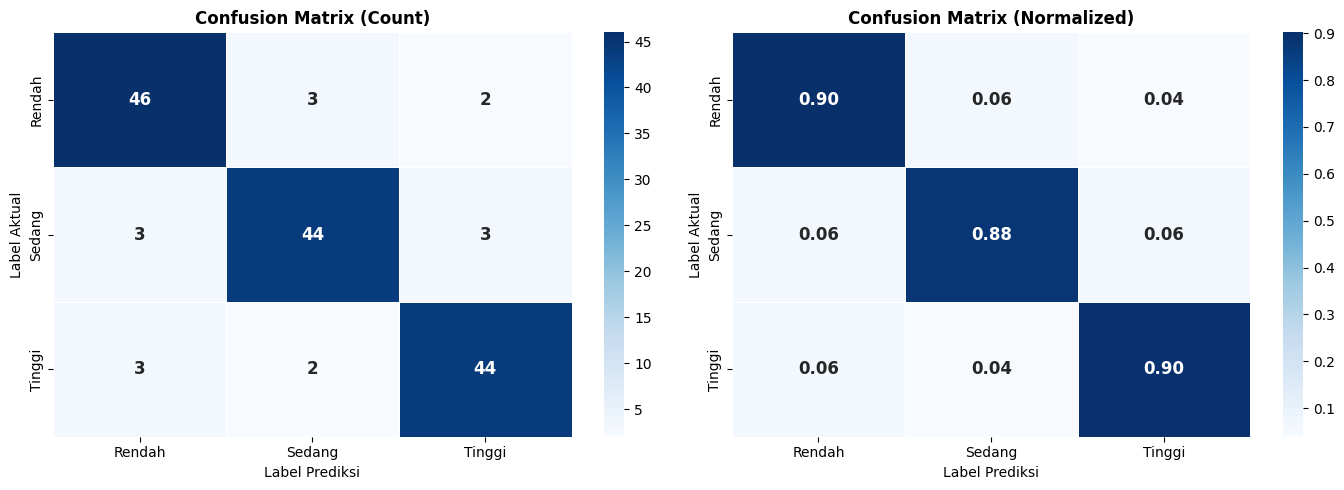

In [ ]:
cm      = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm],
    ["d", ".2f"],
    ["Confusion Matrix (Count)", "Confusion Matrix (Normalized)"]
):
    sns.heatmap(data, annot=True, fmt=fmt,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                cmap="Blues", ax=ax, linewidths=0.5,
                annot_kws={"size": 12, "weight": "bold"})
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel("Label Aktual", fontsize=10)
    ax.set_xlabel("Label Prediksi", fontsize=10)

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


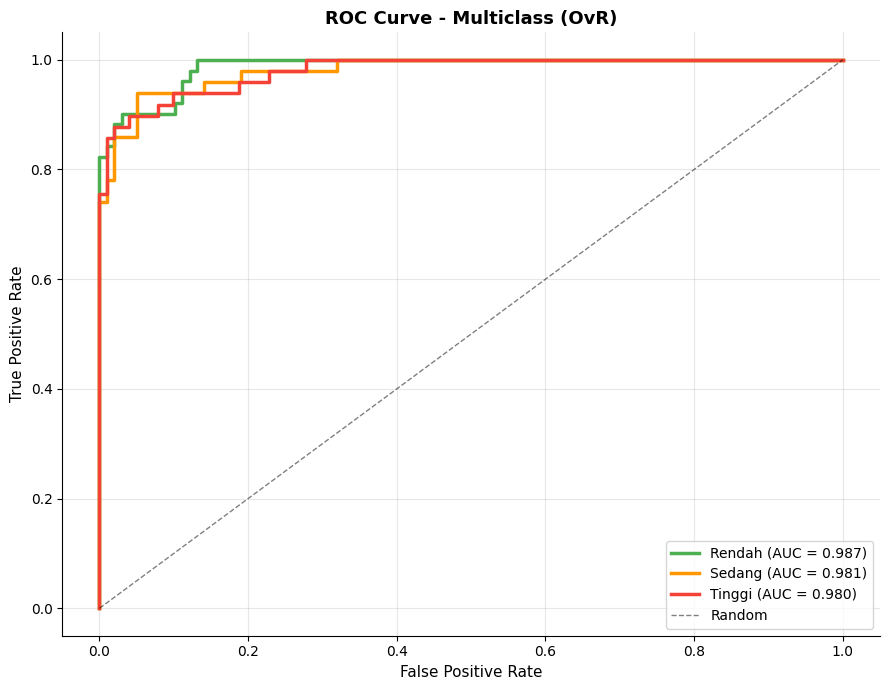

Macro-average ROC AUC : 0.9827


In [ ]:
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
roc_colors = ["#4CAF50", "#FF9800", "#F44336"]

plt.figure(figsize=(9, 7))
for i, (cls, color) in enumerate(zip(CLASS_NAMES, roc_colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    auc_val      = roc_auc_score(y_test_bin[:, i], y_pred_prob[:, i])
    plt.plot(fpr, tpr, color=color, lw=2.5, label="{} (AUC = {:.3f})".format(cls, auc_val))

plt.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="Random")
plt.xlabel("False Positive Rate", fontsize=11)
plt.ylabel("True Positive Rate", fontsize=11)
plt.title("ROC Curve - Multiclass (OvR)", fontsize=13, fontweight="bold")
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
sns.despine()
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

macro_auc = roc_auc_score(y_test_bin, y_pred_prob, average="macro")
print("Macro-average ROC AUC :", round(macro_auc, 4))


---
## Step 20 - Simpan Model dan Artefak

In [ ]:
KERAS_PATH  = "stress_mlp_final.keras"
H5_PATH     = "stress_mlp_final.h5"
SCALER_PATH = "scaler_params.json"

kept_models[0].save(KERAS_PATH)
print("Model utama disimpan (.keras) :", KERAS_PATH)

kept_models[0].save(H5_PATH)
print("Model utama disimpan (.h5)    :", H5_PATH)

scaler_params = {
    "mean_"   : scaler.mean_.tolist(),
    "scale_"  : scaler.scale_.tolist(),
    "features": FEATURE_COLS,
    "n_models": len(kept_models),
}
with open(SCALER_PATH, "w") as f:
    json.dump(scaler_params, f, indent=2)
print("Scaler params disimpan        :", SCALER_PATH)

kept_indices   = [i for i, keep in enumerate(mask) if keep]
ensemble_paths = ["ensemble_model_{}.keras".format(i) for i in kept_indices]

meta = {
    "ensemble_paths"  : ensemble_paths,
    "ensemble_weights": softmax_weights.tolist(),
    "temperature"     : float(best_temp),
    "features"        : FEATURE_COLS,
    "class_names"     : CLASS_NAMES,
    "n_models"        : len(kept_models),
    "scaler_path"     : SCALER_PATH,
    "min_val_acc"     : MIN_VAL_ACC,
}
with open("ensemble_meta.json", "w") as f:
    json.dump(meta, f, indent=2)
print("Ensemble meta disimpan        : ensemble_meta.json")
print("Temperature tersimpan         : {:.2f}".format(best_temp))

for path in [KERAS_PATH, H5_PATH, SCALER_PATH, "ensemble_meta.json"]:
    size = os.path.getsize(path)
    print("OK |", path, "|", size, "bytes")


Model utama disimpan (.keras) : stress_mlp_final.keras
Model utama disimpan (.h5)    : stress_mlp_final.h5
Scaler params disimpan        : scaler_params.json
Ensemble meta disimpan        : ensemble_meta.json
Temperature tersimpan         : 0.95
OK | stress_mlp_final.keras | 1484269 bytes
OK | stress_mlp_final.h5 | 1482912 bytes
OK | scaler_params.json | 1935 bytes
OK | ensemble_meta.json | 1338 bytes


---
## Step 21 - Verifikasi Load Model

In [ ]:
with open("ensemble_meta.json") as f:
    meta = json.load(f)

loaded_ensemble = [
    keras.models.load_model(p, custom_objects=CUSTOM_OBJ)
    for p in meta["ensemble_paths"]
]
loaded_weights = np.array(meta["ensemble_weights"])

print("Model ensemble di-load :", len(loaded_ensemble), "model")
print("Bobot                  :", [round(w, 4) for w in loaded_weights])

sample        = X_test_sc[:5]
probs_orig    = np.average([m.predict(sample, verbose=0) for m in kept_models],
                            axis=0, weights=softmax_weights)
probs_loaded  = np.average([m.predict(sample, verbose=0) for m in loaded_ensemble],
                            axis=0, weights=loaded_weights)
max_diff      = float(np.max(np.abs(probs_orig - probs_loaded)))
print("Maksimum perbedaan probabilitas:", round(max_diff, 10))
print("Prediksi konsisten:", np.allclose(probs_orig, probs_loaded, atol=1e-5))


Model ensemble di-load : 8 model
Bobot                  : [np.float64(0.1263), np.float64(0.1421), np.float64(0.0998), np.float64(0.0998), np.float64(0.0998), np.float64(0.1598), np.float64(0.1598), np.float64(0.1123)]
Maksimum perbedaan probabilitas: 0.0
Prediksi konsisten: True


---
## Step 22 - Ringkasan Akhir

In [ ]:
final_acc = accuracy_score(y_test, y_pred)
final_f1  = f1_score(y_test, y_pred, average="macro")
final_auc = roc_auc_score(label_binarize(y_test, classes=[0,1,2]), y_pred_prob, average="macro")
avg_conf  = float(np.mean(np.max(y_pred_prob, axis=1)))
best_vals = [max(h["val_accuracy"]) for h in ensemble_history]

print("=" * 62)
print("  RINGKASAN MODEL WEIGHTED ENSEMBLE")
print("=" * 62)
print("  Dataset          : final_clean_dataset.csv")
print("  Jumlah sampel    :", len(df_fe))
print("  Fitur            :", len(FEATURE_COLS))
print()
print("  Strategi         : StratifiedKFold {}-Fold + Weighted Ensemble".format(N_FOLDS))
print("  Model dipakai    : {}/{} (val_acc >= {})".format(
    len(kept_models), len(ensemble_models), MIN_VAL_ACC))
print("  Pembobotan       : Softmax berdasarkan val_accuracy")
print("  Arsitektur       : MLP 256-256-128-64 + Residual")
print("  Loss             : CategoricalCE + Label Smoothing 0.05")
print("  Optimizer        : AdamW + Warmup Cosine Decay")
print()
print("  Test Accuracy    : {:.4f} ({:.2f}%)".format(final_acc, final_acc * 100))
print("  Avg Confidence   : {:.4f} ({:.2f}%)".format(avg_conf, avg_conf * 100))
print("  Macro F1-Score   : {:.4f}".format(final_f1))
print("  Macro ROC AUC    : {:.4f}".format(final_auc))
print()
print("=" * 62)


  RINGKASAN MODEL WEIGHTED ENSEMBLE
  Dataset          : final_clean_dataset.csv
  Jumlah sampel    : 1000
  Fitur            : 26

  Strategi         : StratifiedKFold 10-Fold + Weighted Ensemble
  Model dipakai    : 8/10 (val_acc >= 0.87)
  Pembobotan       : Softmax berdasarkan val_accuracy
  Arsitektur       : MLP 256-256-128-64 + Residual
  Loss             : CategoricalCE + Label Smoothing 0.05
  Optimizer        : AdamW + Warmup Cosine Decay

  Test Accuracy    : 0.8933 (89.33%)
  Avg Confidence   : 0.8983 (89.83%)
  Macro F1-Score   : 0.8934
  Macro ROC AUC    : 0.9827



---
## Step 23 - Inference Pipeline

In [ ]:
with open("ensemble_meta.json") as f:
    meta = json.load(f)

inf_ensemble = [
    keras.models.load_model(p, custom_objects=CUSTOM_OBJ)
    for p in meta["ensemble_paths"]
]
inf_weights     = np.array(meta["ensemble_weights"])
inf_temperature = float(meta.get("temperature", 1.0))

with open(meta["scaler_path"]) as f:
    sc_params = json.load(f)

inf_mean  = np.array(sc_params["mean_"])
inf_scale = np.array(sc_params["scale_"])
inf_feats = sc_params["features"]

CLASS_ADVICE = {
    0: "Pola digital dan psikologis Anda terbilang sehat. Pertahankan kebiasaan positif ini.",
    1: "Terdapat indikasi stres sedang. Pertimbangkan mengurangi screen time dan memperbanyak istirahat.",
    2: "Indikasi stres tinggi terdeteksi. Evaluasi jadwal digital, tingkatkan kualitas tidur, dan cari dukungan.",
}

def add_engineered_features(data: dict) -> dict:
    d = data.copy()
    d["screen_to_sleep_ratio"]    = d["Daily_Screen_Time_Hours"] / (d["sleep_quality"] + 1)
    d["social_vs_productivity"]   = d["Social_Media_Usage_Hours"] / (d["Productivity_App_Usage_Hours"] + 0.01)
    d["anxiety_depression_sum"]   = d["anxiety_level"] + d["depression"]
    d["support_pressure_diff"]    = d["social_support"] - d["peer_pressure"]
    d["passive_screen_ratio"]     = (
        d["Social_Media_Usage_Hours"] + d["Gaming_App_Usage_Hours"]
    ) / (d["Total_App_Usage_Hours"] + 0.01)
    d["academic_stress_index"]    = d["study_load"] * d["future_career_concerns"]
    d["wellbeing_deficit"]        = (
        d["anxiety_level"] + d["depression"] + d["peer_pressure"]
    ) - (d["social_support"] * 2 + d["sleep_quality"])
    return d


def apply_temperature(probs, temperature):
    logits = np.log(np.clip(probs, 1e-7, 1.0))
    scaled = logits / temperature
    exp_s  = np.exp(scaled - scaled.max())
    return exp_s / exp_s.sum()


def predict_stress(data: dict, show_detail: bool = True) -> dict:
    enriched = add_engineered_features(data)
    x        = np.array([enriched[f] for f in inf_feats], dtype=np.float32)
    x_scaled = (x - inf_mean) / inf_scale

    probs_all  = [m.predict(x_scaled.reshape(1, -1), verbose=0)[0] for m in inf_ensemble]
    probs_raw  = np.average(probs_all, axis=0, weights=inf_weights)
    probs      = apply_temperature(probs_raw, inf_temperature)
    cls        = int(np.argmax(probs))

    result = {
        "stress_class" : CLASS_NAMES[cls],
        "stress_index" : cls,
        "confidence"   : float(probs[cls]),
        "prob_rendah"  : float(probs[0]),
        "prob_sedang"  : float(probs[1]),
        "prob_tinggi"  : float(probs[2]),
        "rekomendasi"  : CLASS_ADVICE[cls],
    }

    if show_detail:
        bar_max = 35
        print("=" * 60)
        print("  HASIL ANALISIS STRES")
        print("=" * 60)
        print("  Tingkat Stres  :", result["stress_class"].upper())
        print("  Confidence     : {:.1f}%".format(result["confidence"] * 100))
        print()
        print("  Distribusi Probabilitas:")
        for lbl, key in zip(CLASS_NAMES, ["prob_rendah", "prob_sedang", "prob_tinggi"]):
            pct = result[key] * 100
            bar = "#" * int(result[key] * bar_max)
            print("  {:8s}: [{:<{}}] {:5.1f}%".format(lbl, bar, bar_max, pct))
        print()
        print("  Rekomendasi:")
        print(" ", result["rekomendasi"])
        print("=" * 60)

    return result


print("Inference pipeline siap (temperature={:.2f}).".format(inf_temperature))


Inference pipeline siap (temperature=0.95).


---
## Step 24 - Tes Inferensi

In [ ]:
profil_rendah = {
    "anxiety_level": 4, "self_esteem": 25, "mental_health_history": 0,
    "depression": 3, "headache": 1, "sleep_quality": 4,
    "academic_performance": 4, "study_load": 2, "future_career_concerns": 1,
    "social_support": 3, "peer_pressure": 1, "bullying": 0, "Age": 20,
    "Total_App_Usage_Hours": 3.5, "Daily_Screen_Time_Hours": 4.2,
    "Number_of_Apps_Used": 8, "Social_Media_Usage_Hours": 0.8,
    "Productivity_App_Usage_Hours": 2.1, "Gaming_App_Usage_Hours": 0.5,
    "digital_overload_score": 5.2, "productivity_balance_score": 0.6,
    "study_stress_ratio": 0.5, "mental_risk_score": 8,
}
print("--- Profil: Mahasiswa Sehat ---")
r1 = predict_stress(profil_rendah)


--- Profil: Mahasiswa Sehat ---
  HASIL ANALISIS STRES
  Tingkat Stres  : RENDAH
  Confidence     : 99.5%

  Distribusi Probabilitas:
  Rendah  : [################################## ]  99.5%
  Sedang  : [                                   ]   0.4%
  Tinggi  : [                                   ]   0.2%

  Rekomendasi:
  Pola digital dan psikologis Anda terbilang sehat. Pertahankan kebiasaan positif ini.


In [ ]:
profil_sedang = {
    "anxiety_level": 11, "self_esteem": 17, "mental_health_history": 0,
    "depression": 12, "headache": 3, "sleep_quality": 3,
    "academic_performance": 2, "study_load": 3, "future_career_concerns": 3,
    "social_support": 2, "peer_pressure": 3, "bullying": 2, "Age": 21,
    "Total_App_Usage_Hours": 6.5, "Daily_Screen_Time_Hours": 7.8,
    "Number_of_Apps_Used": 17, "Social_Media_Usage_Hours": 2.4,
    "Productivity_App_Usage_Hours": 2.5, "Gaming_App_Usage_Hours": 2.4,
    "digital_overload_score": 12.7, "productivity_balance_score": 0.38,
    "study_stress_ratio": 1.0, "mental_risk_score": 29,
}
print("--- Profil: Mahasiswa Stres Sedang ---")
r2 = predict_stress(profil_sedang)


--- Profil: Mahasiswa Stres Sedang ---
  HASIL ANALISIS STRES
  Tingkat Stres  : SEDANG
  Confidence     : 89.8%

  Distribusi Probabilitas:
  Rendah  : [#                                  ]   3.1%
  Sedang  : [###############################    ]  89.8%
  Tinggi  : [##                                 ]   7.1%

  Rekomendasi:
  Terdapat indikasi stres sedang. Pertimbangkan mengurangi screen time dan memperbanyak istirahat.


In [ ]:
profil_tinggi = {
    "anxiety_level": 19, "self_esteem": 6, "mental_health_history": 1,
    "depression": 22, "headache": 5, "sleep_quality": 1,
    "academic_performance": 1, "study_load": 5, "future_career_concerns": 5,
    "social_support": 1, "peer_pressure": 5, "bullying": 4, "Age": 23,
    "Total_App_Usage_Hours": 10.8, "Daily_Screen_Time_Hours": 12.5,
    "Number_of_Apps_Used": 26, "Social_Media_Usage_Hours": 4.8,
    "Productivity_App_Usage_Hours": 0.4, "Gaming_App_Usage_Hours": 4.2,
    "digital_overload_score": 21.5, "productivity_balance_score": 0.04,
    "study_stress_ratio": 4.8, "mental_risk_score": 52,
}
print("--- Profil: Mahasiswa Stres Tinggi ---")
r3 = predict_stress(profil_tinggi)


--- Profil: Mahasiswa Stres Tinggi ---
  HASIL ANALISIS STRES
  Tingkat Stres  : TINGGI
  Confidence     : 98.8%

  Distribusi Probabilitas:
  Rendah  : [                                   ]   0.8%
  Sedang  : [                                   ]   0.4%
  Tinggi  : [################################## ]  98.8%

  Rekomendasi:
  Indikasi stres tinggi terdeteksi. Evaluasi jadwal digital, tingkatkan kualitas tidur, dan cari dukungan.


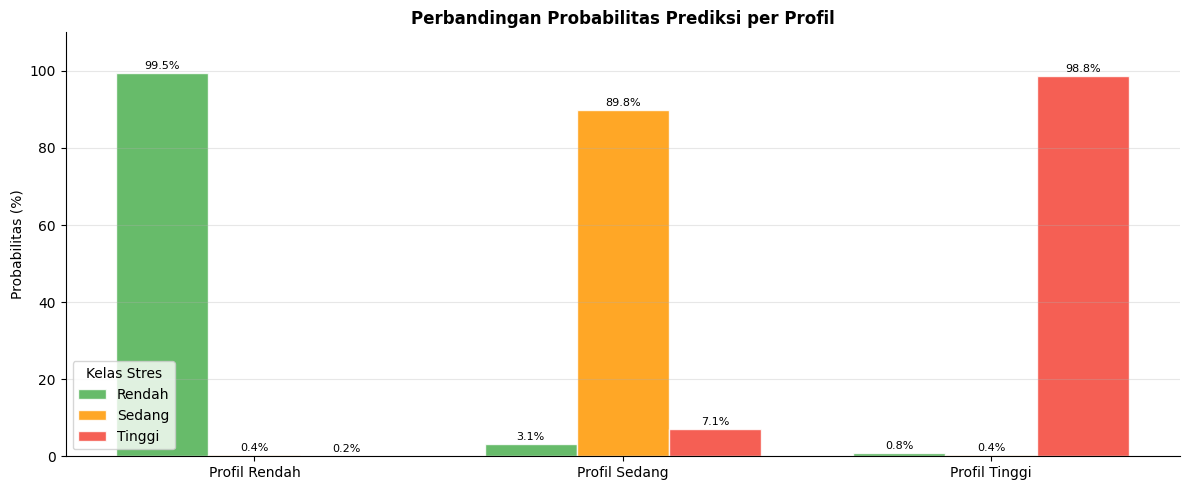

In [ ]:
results = [r1, r2, r3]
labels  = ["Profil Rendah", "Profil Sedang", "Profil Tinggi"]

fig, ax = plt.subplots(figsize=(12, 5))
x       = np.arange(3)
width   = 0.25
colors  = ["#4CAF50", "#FF9800", "#F44336"]

for i, (cls, color) in enumerate(zip(CLASS_NAMES, colors)):
    key  = ["prob_rendah", "prob_sedang", "prob_tinggi"][i]
    vals = [r[key] * 100 for r in results]
    bars = ax.bar(x + i * width, vals, width, label=cls, color=color, alpha=0.85, edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                "{:.1f}%".format(val), ha="center", va="bottom", fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel("Probabilitas (%)")
ax.set_title("Perbandingan Probabilitas Prediksi per Profil", fontsize=12, fontweight="bold")
ax.legend(title="Kelas Stres")
ax.set_ylim(0, 110)
ax.grid(True, alpha=0.3, axis="y")
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig("inference_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Step 25 - Batch Inference dari Test Set

In [ ]:
probs_batch = np.average(
    [m.predict(X_test_sc, verbose=0) for m in kept_models],
    axis=0, weights=softmax_weights
)
preds_all = np.argmax(probs_batch, axis=1)
conf_all  = np.max(probs_batch, axis=1)

results_df = pd.DataFrame({
    "actual"    : [CLASS_NAMES[i] for i in y_test],
    "predicted" : [CLASS_NAMES[i] for i in preds_all],
    "confidence": conf_all.round(4),
    "correct"   : y_test == preds_all,
})

print("=== Ringkasan Batch Inference (Weighted Ensemble) ===")
print("Total sampel    :", len(results_df))
print("Benar           :", results_df["correct"].sum())
print("Salah           :", (~results_df["correct"]).sum())
print("Accuracy        : {:.2f}%".format(results_df["correct"].mean() * 100))
print("Avg Confidence  : {:.4f} ({:.2f}%)".format(conf_all.mean(), conf_all.mean() * 100))
print()
print("Confidence per kelas:")
for cls in CLASS_NAMES:
    subset = results_df[results_df["actual"] == cls]
    print("  {:8s}: avg={:.4f}  min={:.4f}  max={:.4f}".format(
        cls,
        subset["confidence"].mean(),
        subset["confidence"].min(),
        subset["confidence"].max()
    ))


=== Ringkasan Batch Inference (Weighted Ensemble) ===
Total sampel    : 150
Benar           : 134
Salah           : 16
Accuracy        : 89.33%
Avg Confidence  : 0.8916 (89.16%)

Confidence per kelas:
  Rendah  : avg=0.9158  min=0.4214  max=0.9965
  Sedang  : avg=0.8235  min=0.4173  max=0.9753
  Tinggi  : avg=0.9358  min=0.3831  max=0.9967


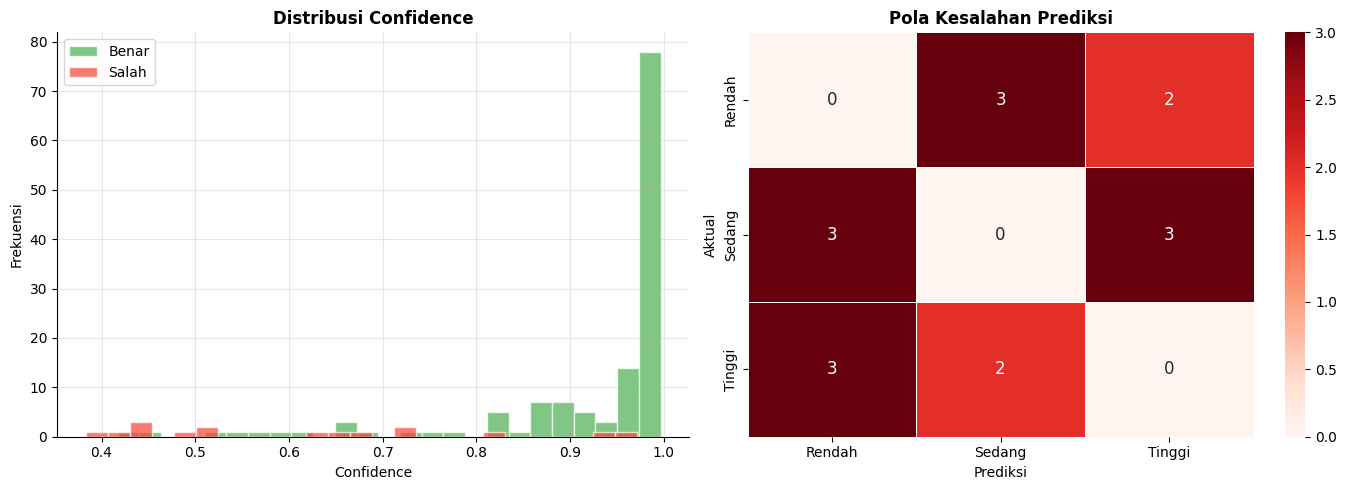

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(conf_all[y_test == preds_all], bins=25, color="#4CAF50",
             alpha=0.7, label="Benar", edgecolor="white")
axes[0].hist(conf_all[y_test != preds_all], bins=25, color="#F44336",
             alpha=0.7, label="Salah", edgecolor="white")
axes[0].set_title("Distribusi Confidence", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Confidence")
axes[0].set_ylabel("Frekuensi")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
sns.despine(ax=axes[0])

wrong_df = results_df[~results_df["correct"]]
if len(wrong_df) > 0:
    error_matrix = pd.crosstab(wrong_df["actual"], wrong_df["predicted"])
    sns.heatmap(error_matrix, annot=True, fmt="d", cmap="Reds",
                ax=axes[1], linewidths=0.5, annot_kws={"size": 12})
    axes[1].set_title("Pola Kesalahan Prediksi", fontsize=12, fontweight="bold")
    axes[1].set_ylabel("Aktual")
    axes[1].set_xlabel("Prediksi")
else:
    axes[1].text(0.5, 0.5, "Tidak ada kesalahan!", ha="center", va="center", fontsize=14)
    axes[1].set_title("Pola Kesalahan Prediksi", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("confidence_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
